(discrete_choice)=
# Discrete Choice and Random Utility Models

:::{post} June, 2023
:tags: categorical regression, generalized linear model, discrete choice, model expansion
:category: advanced, reference
:author: Nathaniel Forde
:::

:::{include} ../extra_installs.md
:::

In [1]:
import arviz as az
import numpy as np  # For vectorized math operations
import pandas as pd  # For file input/output
import pymc as pm
import pytensor.tensor as pt

from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

In [2]:
%config InlineBackend.figure_format = 'retina'  # high resolution figures
az.style.use("arviz-darkgrid")
rng = np.random.default_rng(42)

## Discrete Choice Modelling: The Idea

Discrete choice modelling is related to the idea of a latent utility scale as discussed in {ref}`ordinal_regression`, but it generalises the idea to decision making. It posits that human decision making can be modelled as a function of latent/subjective utility measurements over a set of mutually exclusive alternatives. The theory states that any decision maker will go with the option that maximises their subjective utility, __and__ that utility can be modelled as a latent linear function of observable features of the world. 

The idea is perhaps most famously applied by Daniel McFadden in the 1970s to predict the market share accruing to transportation choices (i.e. car, rail, walking etc..) in California after the proposed introduction of BART light rail system. It's worth pausing on that point. The theory is one of micro level human decision making that has, in real applications, been scaled up to make broadly accurate macro level predictions. For more details we recommend {cite:t}`train2009`

We don't need to be too credulous either. This is merely a statistical model and success here is entirely dependent on the skill of modeller and the available measurements coupled with plausible theory. But it's worth noting the scale of the ambition underlying these models. The structure of the model encourages you to articulate your theory of the decision makers and the environment they inhabit. 

### The Data

In this example, we'll examine the technique of discrete choice modelling using a (i) heating system data set from the R `mlogit` package and (ii) repeat choice data set over cracker brands. We'll be pursuing a Bayesian approach to estimating the models rather than the MLE methodology reported in their vigenette. The first data set shows household choices over offers of heating systems in California.  The observations consist of single-family houses in California that were newly built and had central air-conditioning. Five types of systems are considered to have been possible:

 - gas central (gc),
 - gas room (gr),
 - electric central (ec),
 - electric room (er),
 - heat pump (hp).

The data set reports the installation `ic.alt` and operating costs `oc.alt` each household was faced with for each of the five alternatives with some broad demographic information about the household and crucially the choice `depvar`. This is what one choice scenario over the five alternative looks like in the data:


In [3]:
try:
    wide_heating_df = pd.read_csv("../data/heating_data_r.csv")
except:
    wide_heating_df = pd.read_csv(pm.get_data("heating_data_r.csv"))

wide_heating_df[wide_heating_df["idcase"] == 1]

,idcase,depvar,ic.gc,ic.gr,ic.ec,ic.er,ic.hp,oc.gc,oc.gr,oc.ec,oc.er,oc.hp,income,agehed,rooms,region
0,1,gc,866.0,962.64,859.9,995.76,1135.5,199.69,151.72,553.34,505.6,237.88,7,25,6,ncostl


The core idea of these kinds of models is to conceive of this scenario as a choice over exhaustive options with attached latent utility. The utility ascribed to each option is viewed as a linear combination of the attributes for each option. The utility ascribed to each alternative drives the probability of choosing amongst each option. For each $j$ in all the alternatives $Alt = \{ gc, gr, ec, er, hp \}$ which is assumed to take a Gumbel distribution because this has a particularly nice mathematical property. 

$$ \mathbf{U} \sim Gumbel $$

$$ \begin{pmatrix}
u_{gc}   \\
u_{gr}   \\
u_{ec}   \\
u_{er}   \\
u_{hp}   \\
\end{pmatrix} =  \begin{pmatrix}
gc_{ic} & gc_{oc}  \\
gr_{ic} & gr_{oc}  \\
ec_{ic} & ec_{oc}  \\
er_{ic} & er_{oc}  \\
hp_{ic} & hp_{oc}  \\
\end{pmatrix} \begin{pmatrix}
\beta_{ic}   \\
\beta_{oc}   \\
\end{pmatrix}  $$

This assumption proves to be mathematically convenient because the difference between two Gumbel distributions can be modelled as a logistic function, meaning we can model a contrast difference among multiple alternatives with the softmax function. Details of the derivation can be found in {cite:t}`train2009`

$$ \text{softmax}(u)_{j} = \frac{\exp(u_{j})}{\sum_{q=1}^{J}\exp(u_{q})} $$

The model then assumes that decision maker chooses the option that maximises their subjective utility. The individual utility functions can be richly parameterised. The model is identified just when the utility measures of the alternatives are benchmarked against the fixed utility of the "outside good." The last quantity is often fixed at 0 to aid parameter identification on alternative-specific parameters as we'll see below.

$$\begin{pmatrix}
u_{gc}   \\
u_{gr}   \\
u_{ec}   \\
u_{er}   \\
0   \\
\end{pmatrix}
$$

With all these constraints applied we can build out conditional random utility model and it's hierarchical variants. Like nearly all subjects in statistics the precise vocabulary for the model specification is overloaded. The conditional logit parameters $\beta$
may be fixed at the level of the individual, but can vary across individuals and the alternatives `gc, gr, ec, er` too. In this manner we can compose an elaborate theory of how we expect drivers of subjective utility to change the market share amongst a set of competing goods.

### Digression on Data Formats

Discrete choice models are often estimated using a long-data format where each choice scenario is represented with a row per alternative ID and a binary flag denoting the chosen option in each scenario. This data format is recommended for estimating these kinds of models in `stan` and in `pylogit`. The reason for doing this is that once the columns `installation_costs` and `operating_costs` have been pivoted in this fashion it's easier to include them in matrix calculations. 



In [4]:
try:
    long_heating_df = pd.read_csv("../data/long_heating_data.csv")
except:
    long_heating_df = pd.read_csv(pm.get_data("long_heating_data.csv"))

columns = [c for c in long_heating_df.columns if c != "Unnamed: 0"]
long_heating_df[long_heating_df["idcase"] == 1][columns]

,idcase,alt_id,choice,depvar,income,agehed,rooms,region,installation_costs,operating_costs
0,1,1,1,gc,7,25,6,ncostl,866.00,199.69
1,1,2,0,gc,7,25,6,ncostl,962.64,151.72
2,1,3,0,gc,7,25,6,ncostl,859.90,553.34
3,1,4,0,gc,7,25,6,ncostl,995.76,505.60
4,1,5,0,gc,7,25,6,ncostl,1135.50,237.88


## The Basic Model

We will show here how to incorporate the utility specifications in PyMC. PyMC is a nice interface for this kind of modelling because it can express the model quite cleanly following the natural mathematical expression for this system of equations. You can see in this simple model how we go about constructing equations for the utility measure of each alternative seperately, and then stacking them together to create the input matrix for our softmax transform. 

Sampling: [beta_ic, beta_oc, y_cat]
/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/pymc/sampling/mcmc.py:243: UserWarning: Use of external NUTS sampler is still experimental
  warnings.warn("Use of external NUTS sampler is still experimental", UserWarning)


Compiling...
Compilation time =  0:00:01.195286
Sampling...


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Sampling time =  0:00:02.097556
Transforming variables...
Transformation time =  0:00:00.396818
Computing Log Likelihood...


Sampling: [y_cat]


Log Likelihood time =  0:00:00.638968


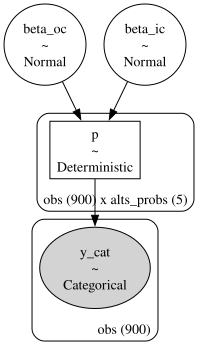

In [5]:
N = wide_heating_df.shape[0]
observed = pd.Categorical(wide_heating_df["depvar"]).codes
coords = {
    "alts_probs": ["ec", "er", "gc", "gr", "hp"],
    "obs": range(N),
}

with pm.Model(coords=coords) as model_1:
    beta_ic = pm.Normal("beta_ic", 0, 1)
    beta_oc = pm.Normal("beta_oc", 0, 1)

    ## Construct Utility matrix and Pivot
    u0 = beta_ic * wide_heating_df["ic.ec"] + beta_oc * wide_heating_df["oc.ec"]
    u1 = beta_ic * wide_heating_df["ic.er"] + beta_oc * wide_heating_df["oc.er"]
    u2 = beta_ic * wide_heating_df["ic.gc"] + beta_oc * wide_heating_df["oc.gc"]
    u3 = beta_ic * wide_heating_df["ic.gr"] + beta_oc * wide_heating_df["oc.gr"]
    u4 = beta_ic * wide_heating_df["ic.hp"] + beta_oc * wide_heating_df["oc.hp"]
    s = pm.math.stack([u0, u1, u2, u3, u4]).T

    ## Apply Softmax Transform
    p_ = pm.Deterministic("p", pm.math.softmax(s, axis=1), dims=("obs", "alts_probs"))

    ## Likelihood
    choice_obs = pm.Categorical("y_cat", p=p_, observed=observed, dims="obs")

    idata_m1 = pm.sample_prior_predictive()
    idata_m1.extend(
        pm.sample(nuts_sampler="numpyro", idata_kwargs={"log_likelihood": True}, random_seed=101)
    )
    idata_m1.extend(pm.sample_posterior_predictive(idata_m1))

pm.model_to_graphviz(model_1)

Note that you need to be careful with the encoding of the outcome variable. The categorical ordering should reflect the ordering of the utilities as they are stacked into the softmax transform and then fed into the likelihood term. 

In [6]:
idata_m1

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [7]:
summaries = az.summary(idata_m1, var_names=["beta_ic", "beta_oc"])
summaries

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_ic,-0.006,0.0,-0.007,-0.006,0.0,0.0,3325.0,2691.0,1.0
beta_oc,-0.005,0.0,-0.005,-0.004,0.0,0.0,3777.0,2784.0,1.0


In the `mlogit` vignette they report how the above model specification leads to inadequate parameter estimates. They note for instance that while the utility scale itself is hard to interpret the value of the ratio of the coefficients is often meaningful because when:

$$ U = \beta_{oc}oc + \beta_{ic}ic $$

then the marginal rate of substitution is just the ratio of the two beta coefficients. The relative importance of one component of the utility equation to another is an economically meaningful quantity even if the notion of subjective utility is itself unobservable. 

$$ dU = \beta_{ic} dic + \beta_{oc} doc = 0 \Rightarrow 
-\frac{dic}{doc}\mid_{dU=0}=\frac{\beta_{oc}}{\beta_{ic}}$$

Our parameter estimates differ slightly from the reported estimates, but we agree the model is inadequate. We will show a number of Bayesian model checks to demonstrate this fact, but the main call out is that the parameter values for installation costs should probably be negative. It's counter-intuitive that a $\beta_{ic}$ increase in price would increase the utility of generated by the installation even marginally as here. Although we might imagine that some kind of quality assurance comes with price which drives satisfaction with higher installation costs. The coefficient for repeat operating costs is negative as expected. Putting this issue aside for now, we'll show below how we can incorporate prior knowledge to adjust for this kind of conflicts with theory. 

But in any case, once we have a fitted model we can calculate the marginal rate of substitution as follows:


In [8]:
## marginal rate of substitution for a reduction in installation costs
post = az.extract(idata_m1)
substitution_rate = post["beta_oc"] / post["beta_ic"]
substitution_rate.mean().item()

0.7377857195962645

This statistic gives a view of the relative importance of the attributes which drive our utility measures. But being good Bayesians we actually want to calculate the posterior distribution for this statistic.

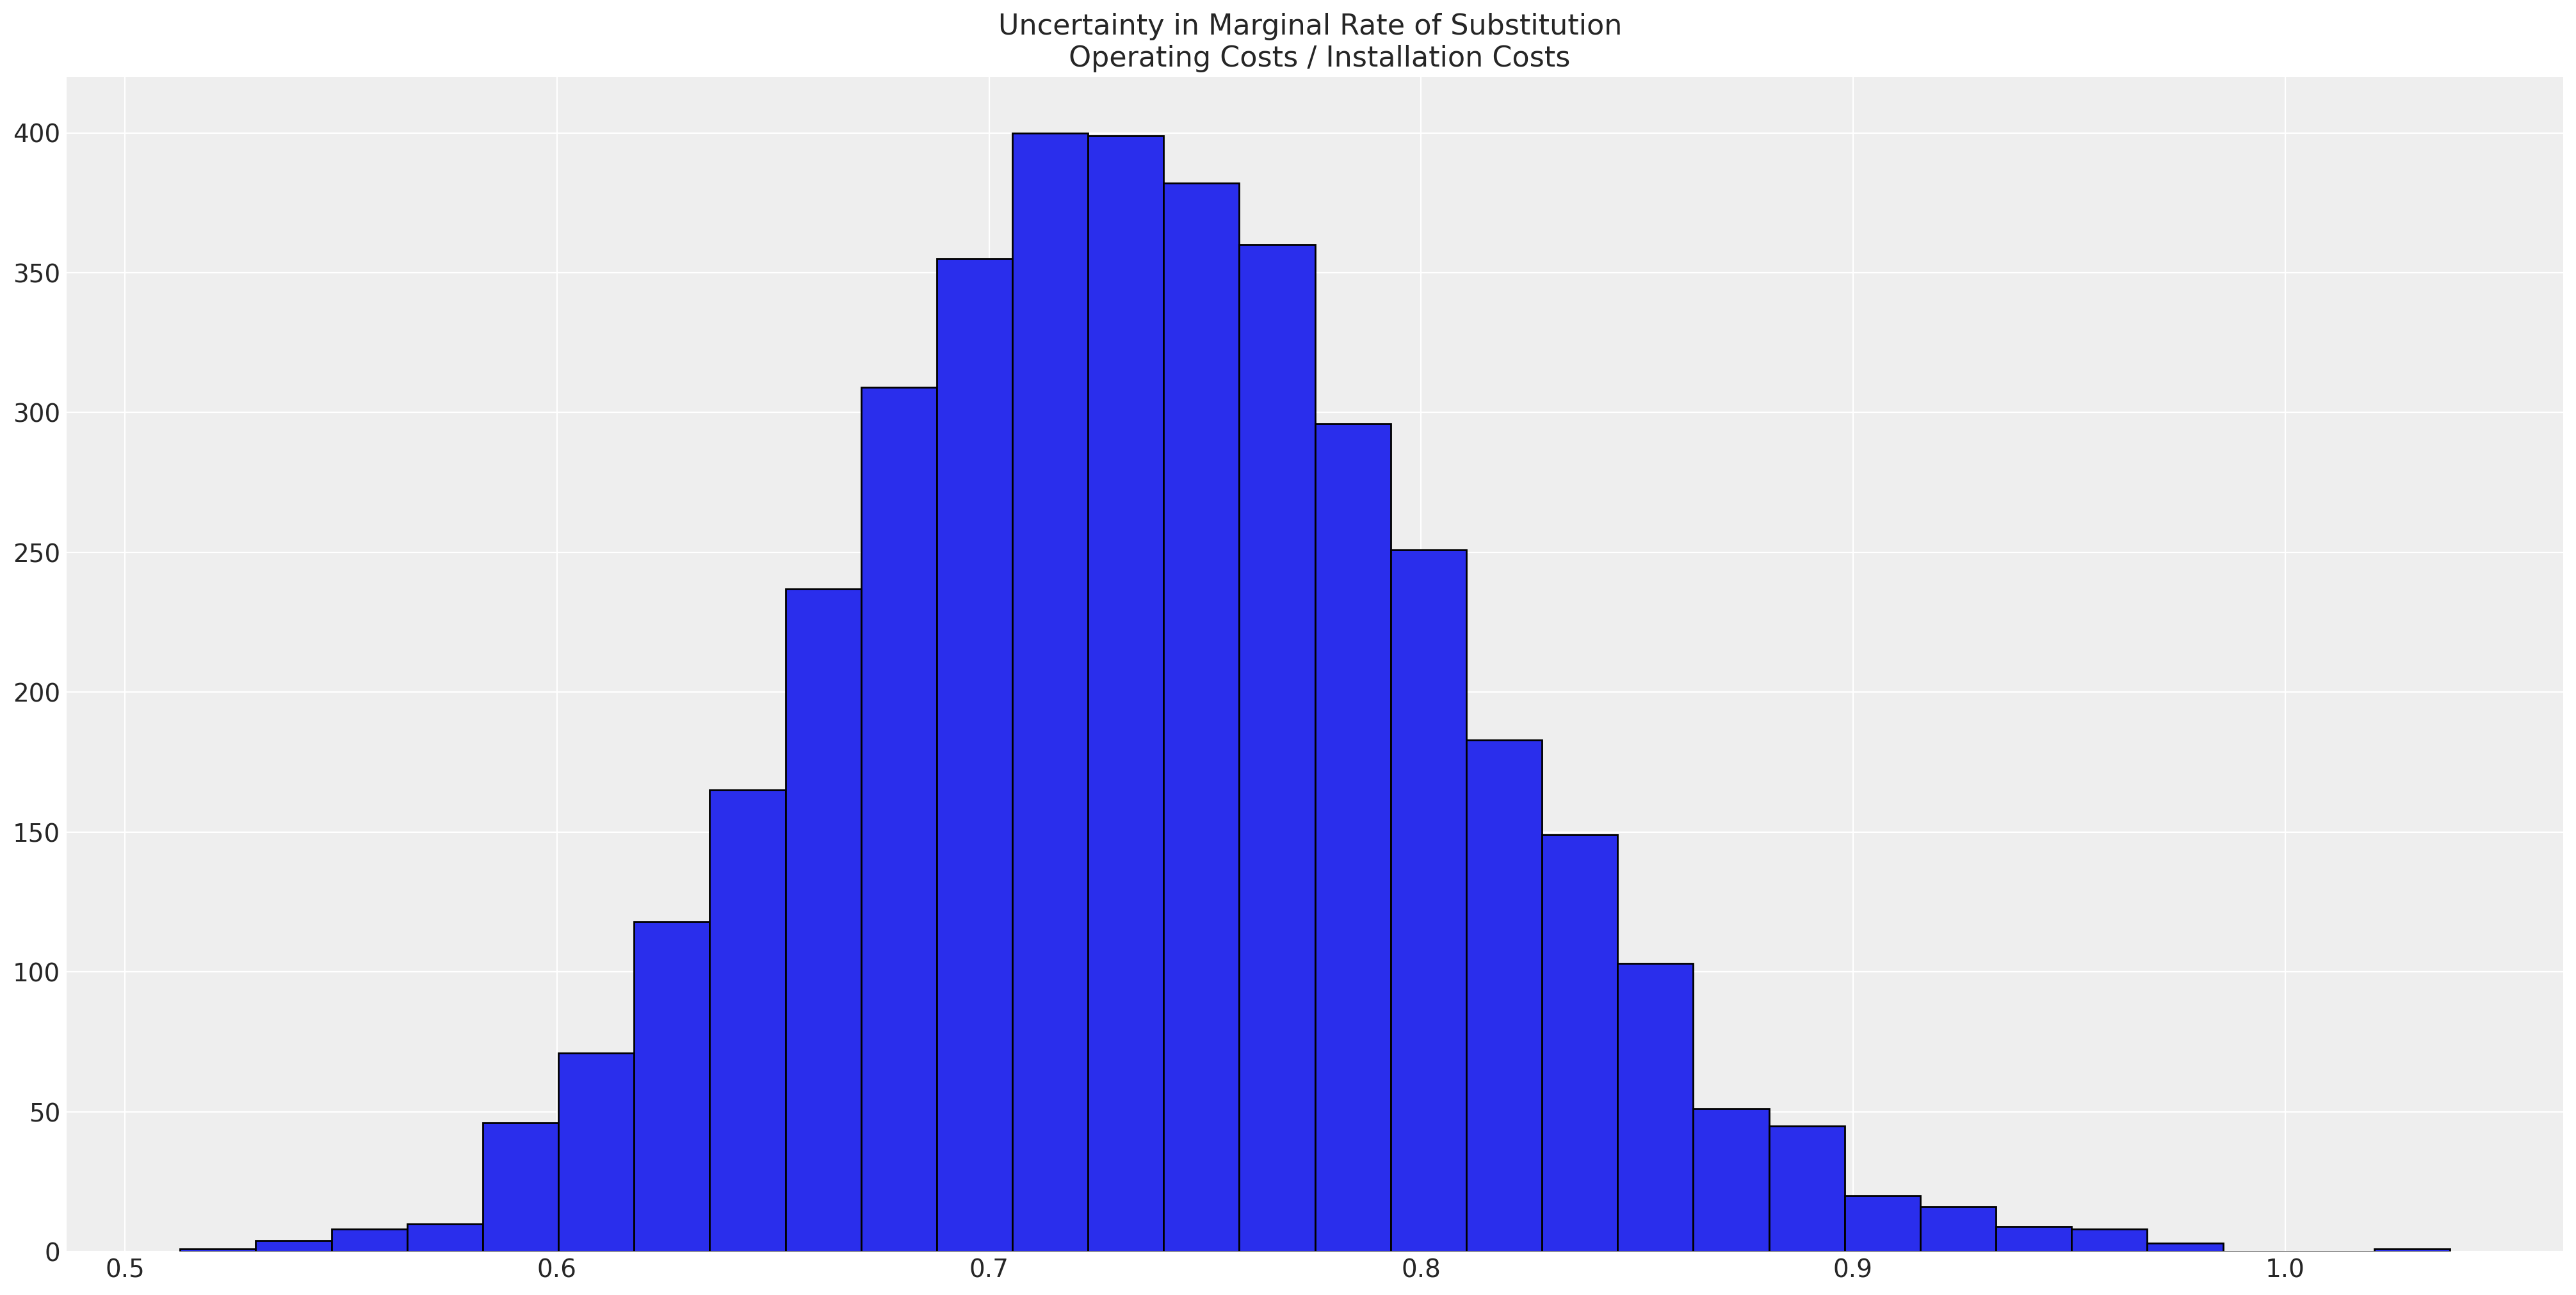

In [9]:
fig, ax = plt.subplots(figsize=(20, 10))

ax.hist(
    substitution_rate,
    bins=30,
    ec="black",
)
ax.set_title("Uncertainty in Marginal Rate of Substitution \n Operating Costs / Installation Costs");

which suggests that there is around .7 of the value accorded to the a unit reduction in recurring operating costs over the one-off installation costs. Whether this is remotely plausible is almost beside the point since the model does not even closely capture the data generating process. But it's worth repeating that the native scale of utility is not straightforwardly meaningful, but the ratio of the coefficients in the utility equations can be directly interpreted.  

To assess overall model adequacy we can rely on the posterior predictive checks to see if the model can recover an approximation to the data generating process.

In [10]:
idata_m1["posterior"]["p"].mean(dim=["chain", "draw", "obs"])

<xarray.DataArray 'p' (alts_probs: 5)>
array([0.10421251, 0.05138074, 0.51701653, 0.24023285, 0.08715736])
Coordinates:
  * alts_probs  (alts_probs) <U2 'ec' 'er' 'gc' 'gr' 'hp'

/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/arviz/plots/ppcplot.py:267: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten_pp = list(predictive_dataset.dims.keys())
/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/arviz/plots/ppcplot.py:271: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten = list(observed_data.dims.keys())


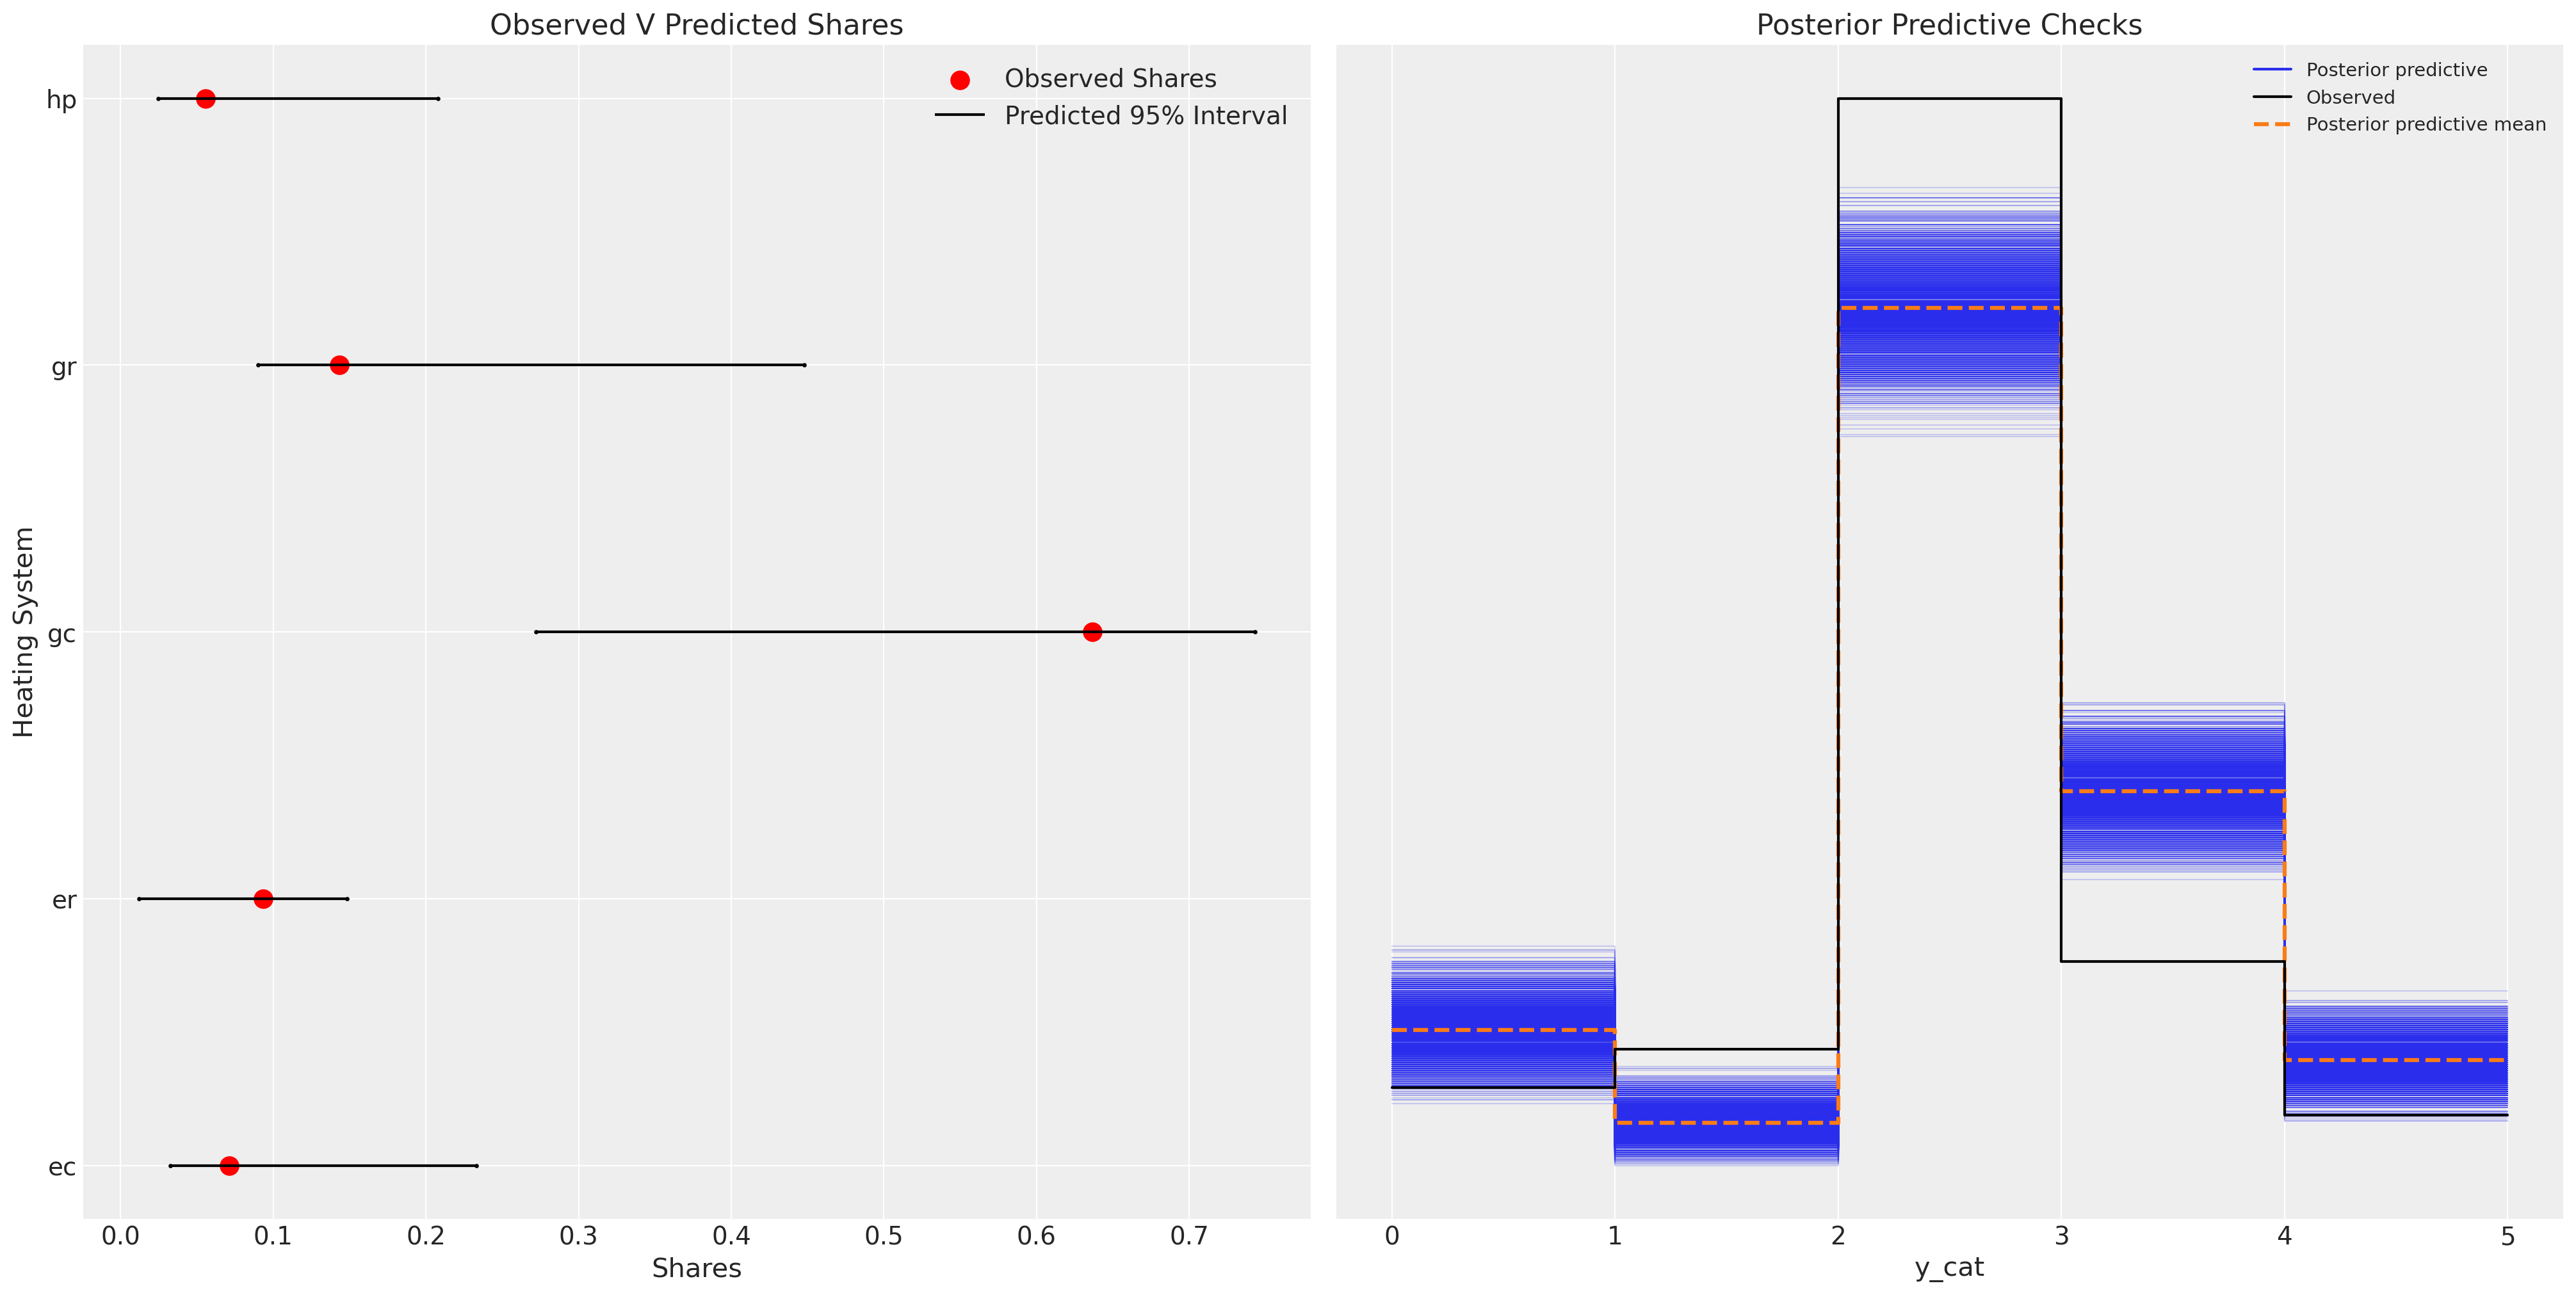

In [11]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
ax = axs[0]
counts = wide_heating_df.groupby("depvar")["idcase"].count()
predicted_shares = idata_m1["posterior"]["p"].mean(dim=["chain", "draw", "obs"])
ci_lb = idata_m1["posterior"]["p"].quantile(0.025, dim=["chain", "draw", "obs"])
ci_ub = idata_m1["posterior"]["p"].quantile(0.975, dim=["chain", "draw", "obs"])
ax.scatter(ci_lb, ["ec", "er", "gc", "gr", "hp"], color="k", s=2)
ax.scatter(ci_ub, ["ec", "er", "gc", "gr", "hp"], color="k", s=2)
ax.scatter(
    counts / counts.sum(),
    ["ec", "er", "gc", "gr", "hp"],
    label="Observed Shares",
    color="red",
    s=100,
)
ax.hlines(
    ["ec", "er", "gc", "gr", "hp"], ci_lb, ci_ub, label="Predicted 95% Interval", color="black"
)
ax.legend()
ax.set_title("Observed V Predicted Shares")
az.plot_ppc(idata_m1, ax=axs[1])
axs[1].set_title("Posterior Predictive Checks")
ax.set_xlabel("Shares")
ax.set_ylabel("Heating System");

We can see here that the model is fairly inadequate, and fails quite dramatically to recapture the posterior predictive distribution. 

## Improved Model: Adding Alternative Specific Intercepts

We can address some of the issues with the prior model specification by adding intercept terms for each of the unique alternatives `gr, gc, ec, er`. These terms will absorb some of the error seen in the last model by allowing us to control some of the heterogenity of utility measures across products. 

Sampling: [alpha, beta_ic, beta_oc, y_cat]
/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/pymc/sampling/mcmc.py:243: UserWarning: Use of external NUTS sampler is still experimental
  warnings.warn("Use of external NUTS sampler is still experimental", UserWarning)


Compiling...
Compilation time =  0:00:01.074196
Sampling...


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Sampling time =  0:00:12.000761
Transforming variables...
Transformation time =  0:00:00.295025
Computing Log Likelihood...


Sampling: [y_cat]


Log Likelihood time =  0:00:00.411164


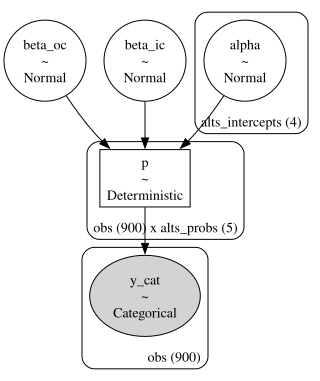

In [12]:
N = wide_heating_df.shape[0]
observed = pd.Categorical(wide_heating_df["depvar"]).codes

coords = {
    "alts_intercepts": ["ec", "er", "gc", "gr"],
    "alts_probs": ["ec", "er", "gc", "gr", "hp"],
    "obs": range(N),
}
with pm.Model(coords=coords) as model_2:
    beta_ic = pm.Normal("beta_ic", 0, 1)
    beta_oc = pm.Normal("beta_oc", 0, 1)
    alphas = pm.Normal("alpha", 0, 1, dims="alts_intercepts")

    ## Construct Utility matrix and Pivot using an intercept per alternative
    u0 = alphas[0] + beta_ic * wide_heating_df["ic.ec"] + beta_oc * wide_heating_df["oc.ec"]
    u1 = alphas[1] + beta_ic * wide_heating_df["ic.er"] + beta_oc * wide_heating_df["oc.er"]
    u2 = alphas[2] + beta_ic * wide_heating_df["ic.gc"] + beta_oc * wide_heating_df["oc.gc"]
    u3 = alphas[3] + beta_ic * wide_heating_df["ic.gr"] + beta_oc * wide_heating_df["oc.gr"]
    u4 = 0 + beta_ic * wide_heating_df["ic.hp"] + beta_oc * wide_heating_df["oc.hp"]
    s = pm.math.stack([u0, u1, u2, u3, u4]).T

    ## Apply Softmax Transform
    p_ = pm.Deterministic("p", pm.math.softmax(s, axis=1), dims=("obs", "alts_probs"))

    ## Likelihood
    choice_obs = pm.Categorical("y_cat", p=p_, observed=observed, dims="obs")

    idata_m2 = pm.sample_prior_predictive()
    idata_m2.extend(
        pm.sample(nuts_sampler="numpyro", idata_kwargs={"log_likelihood": True}, random_seed=103)
    )
    idata_m2.extend(pm.sample_posterior_predictive(idata_m2))


pm.model_to_graphviz(model_2)

We have deliberately 0'd out the intercept parameter for the `hp` alternative to ensure parameter identification is feasible. 

In [13]:
az.summary(idata_m2, var_names=["beta_ic", "beta_oc", "alpha"], round_to=4)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_ic,-0.0019,0.0006,-0.0030,-0.0007,0.0000,0.0000,2194.2030,2974.0194,1.0004
beta_oc,-0.0058,0.0013,-0.0082,-0.0032,0.0000,0.0000,1317.1605,1482.4796,1.0008
alpha[ec],1.1859,0.3856,0.4164,1.8939,0.0111,0.0079,1208.3253,1521.0849,1.0009
alpha[er],1.4859,0.3102,0.8716,2.0489,0.0088,0.0063,1244.2319,1021.4642,1.0009
alpha[gc],1.6028,0.2169,1.1950,2.0159,0.0060,0.0043,1319.9286,1489.0237,1.0011
alpha[gr],0.2644,0.1925,-0.0933,0.6262,0.0051,0.0037,1408.3095,1595.1160,1.0011


We can see now how this model performs much better in capturing aspects of the data generating process. 

/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/arviz/plots/ppcplot.py:267: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten_pp = list(predictive_dataset.dims.keys())
/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/arviz/plots/ppcplot.py:271: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten = list(observed_data.dims.keys())


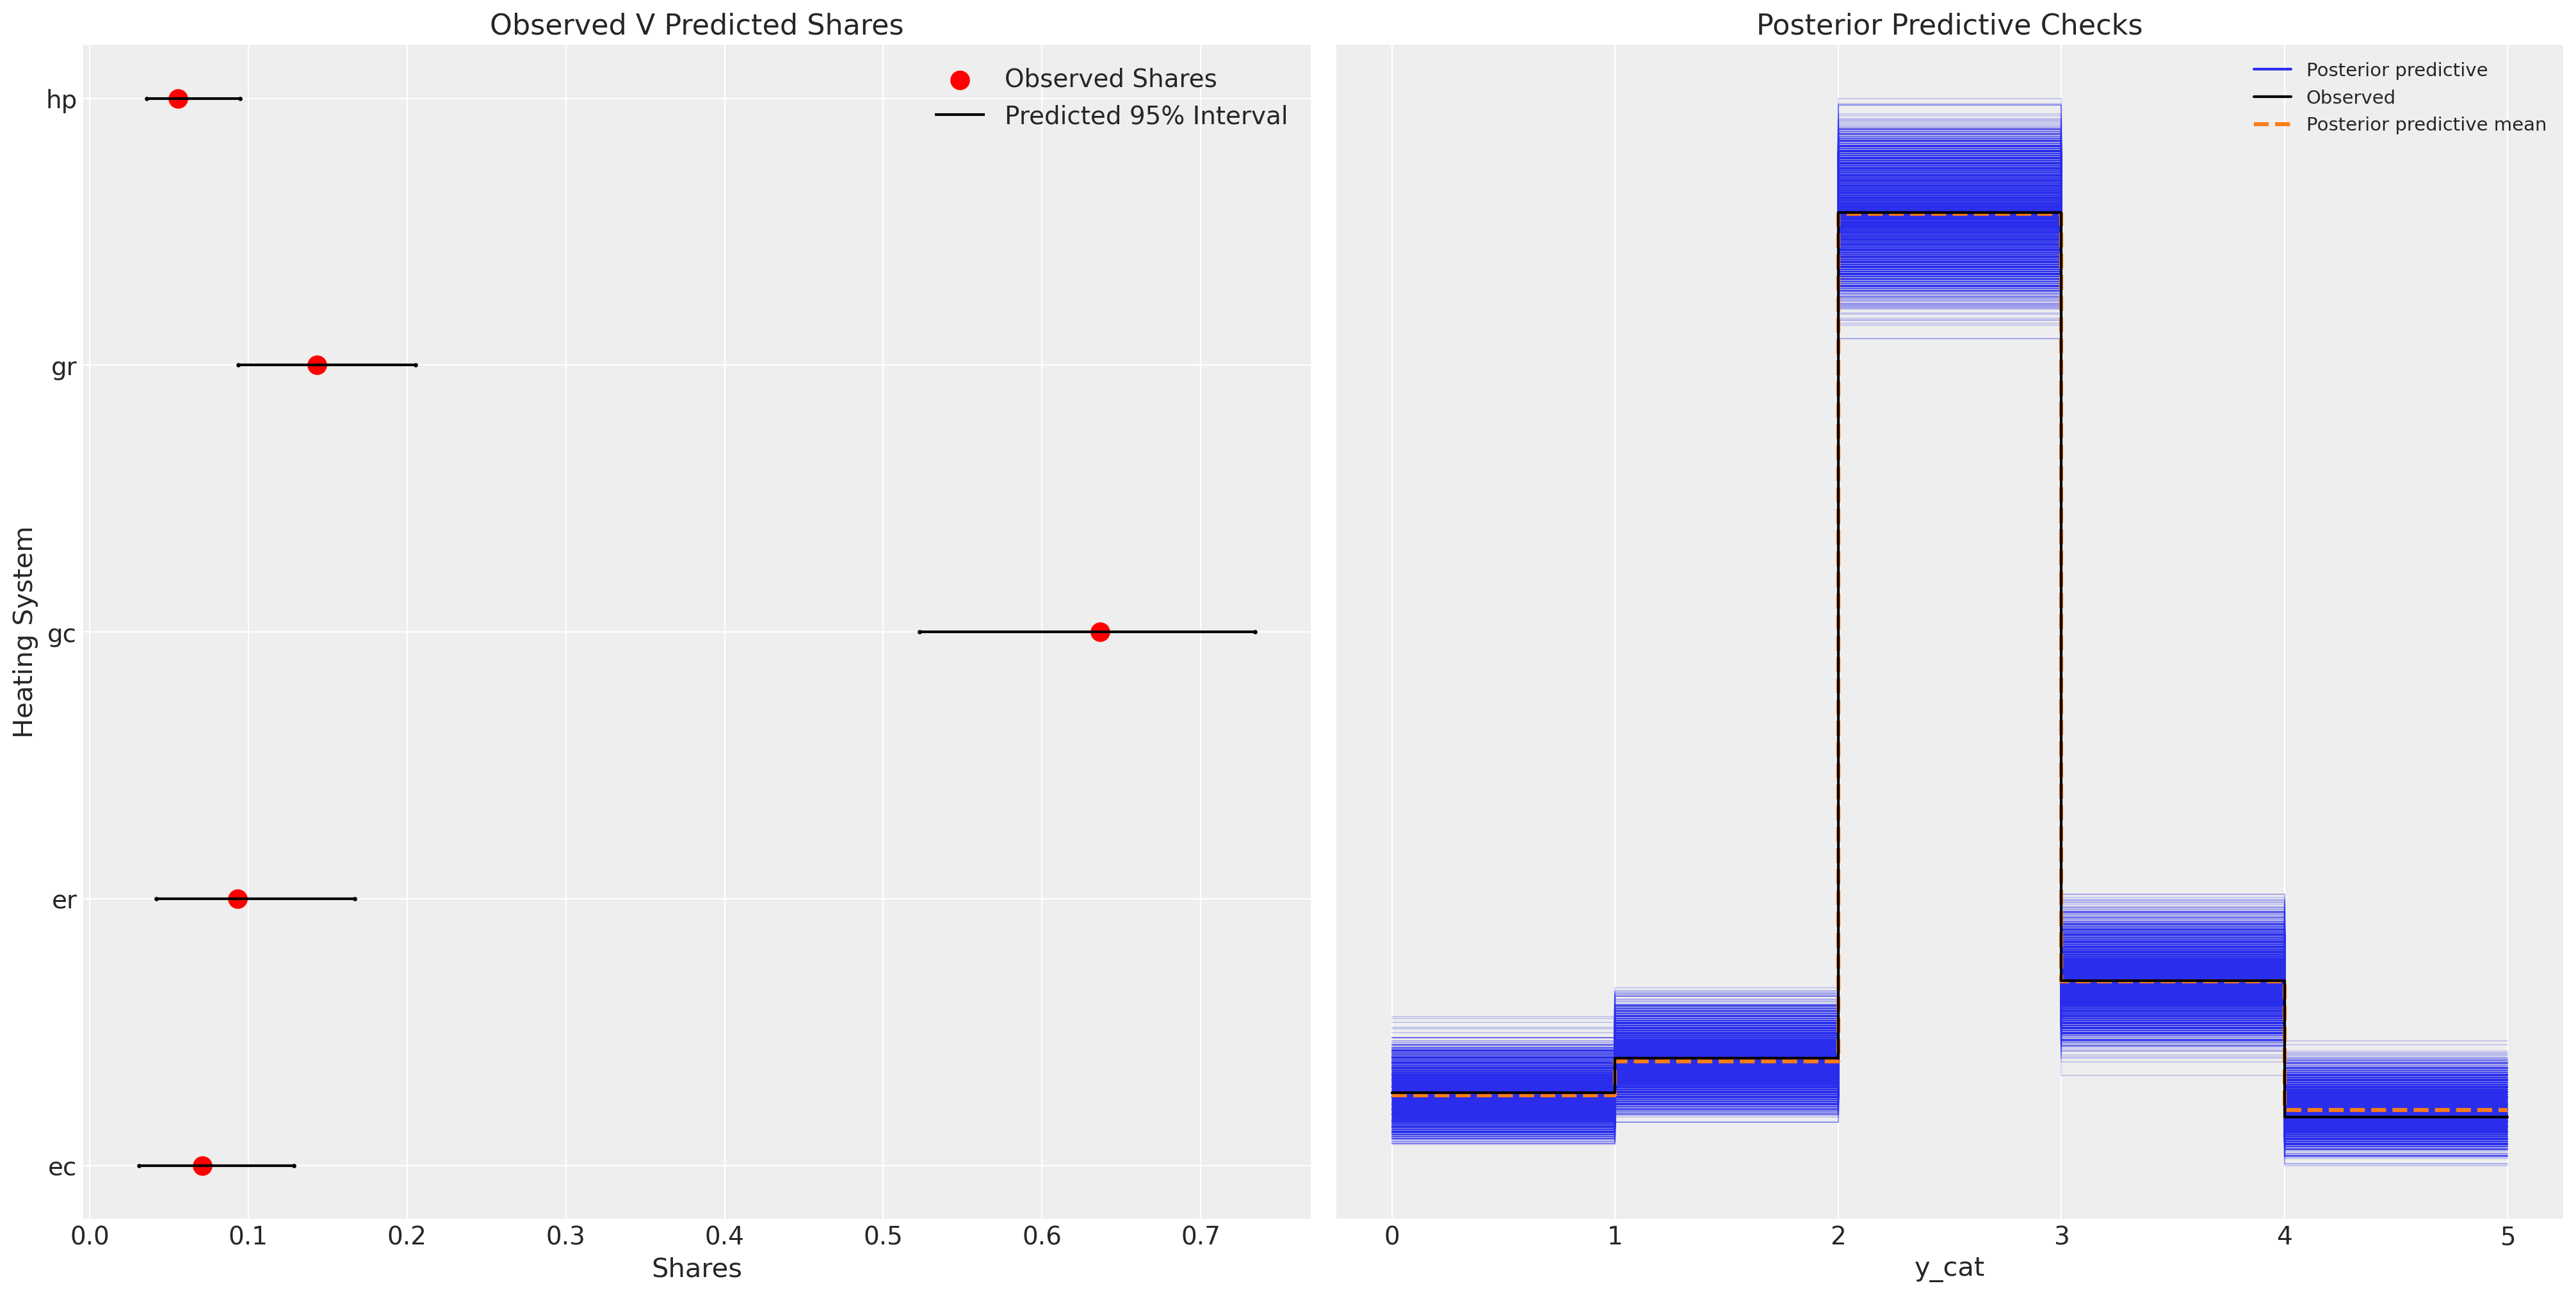

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
ax = axs[0]
counts = wide_heating_df.groupby("depvar")["idcase"].count()
predicted_shares = idata_m2["posterior"]["p"].mean(dim=["chain", "draw", "obs"])
ci_lb = idata_m2["posterior"]["p"].quantile(0.025, dim=["chain", "draw", "obs"])
ci_ub = idata_m2["posterior"]["p"].quantile(0.975, dim=["chain", "draw", "obs"])

ax.scatter(ci_lb, ["ec", "er", "gc", "gr", "hp"], color="k", s=2)
ax.scatter(ci_ub, ["ec", "er", "gc", "gr", "hp"], color="k", s=2)
ax.scatter(
    counts / counts.sum(),
    ["ec", "er", "gc", "gr", "hp"],
    label="Observed Shares",
    color="red",
    s=100,
)
ax.hlines(
    ["ec", "er", "gc", "gr", "hp"], ci_lb, ci_ub, label="Predicted 95% Interval", color="black"
)
ax.legend()
ax.set_title("Observed V Predicted Shares")
az.plot_ppc(idata_m2, ax=axs[1])
axs[1].set_title("Posterior Predictive Checks")
ax.set_xlabel("Shares")
ax.set_ylabel("Heating System");

This model represents a substantial improvement. 

## Experimental Model: Adding Correlation Structure

We might think that there is a correlation among the alternative goods that we should capture too. We can capture those effects in so far as they exist by placing a multvariate normal prior on the intercepts, (or alternatively the beta parameters). In addition we add information about how the effect of income influences the utility accorded to each alternative. 

Sampling: [alpha, beta_ic, beta_oc, chol, y_cat]
/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/pymc/sampling/mcmc.py:243: UserWarning: Use of external NUTS sampler is still experimental
  warnings.warn("Use of external NUTS sampler is still experimental", UserWarning)


Compiling...
Compilation time =  0:00:02.342931
Sampling...


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Sampling time =  0:00:23.358412
Transforming variables...
Transformation time =  0:00:00.553256
Computing Log Likelihood...


Sampling: [y_cat]


Log Likelihood time =  0:00:00.446564


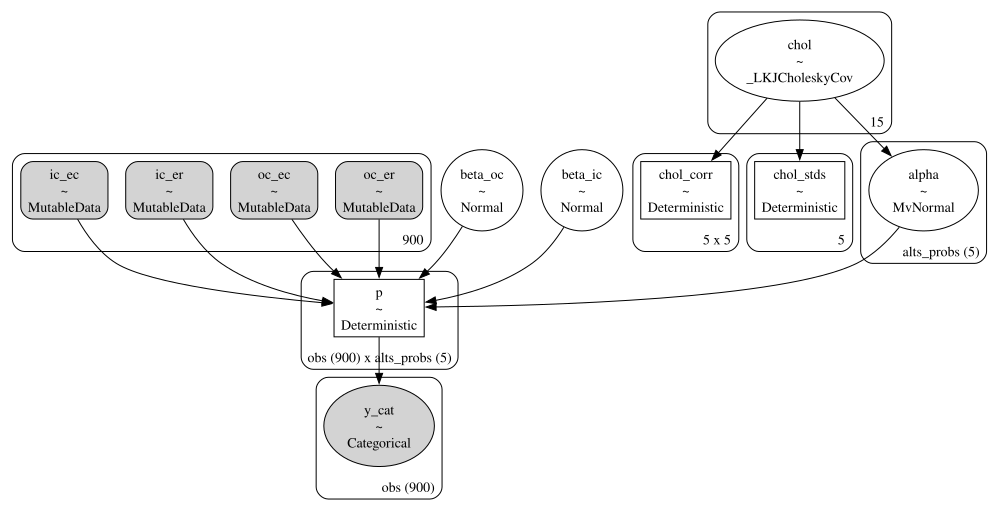

In [15]:
coords = {
    "alts_intercepts": ["ec", "er", "gc", "gr"],
    "alts_probs": ["ec", "er", "gc", "gr", "hp"],
    "obs": range(N),
}
with pm.Model(coords=coords) as model_3:
    ## Add data to experiment with changes later.
    ic_ec = pm.MutableData("ic_ec", wide_heating_df["ic.ec"])
    oc_ec = pm.MutableData("oc_ec", wide_heating_df["oc.ec"])
    ic_er = pm.MutableData("ic_er", wide_heating_df["ic.er"])
    oc_er = pm.MutableData("oc_er", wide_heating_df["oc.er"])

    beta_ic = pm.Normal("beta_ic", 0, 1)
    beta_oc = pm.Normal("beta_oc", 0, 1)
    chol, corr, stds = pm.LKJCholeskyCov(
        "chol", n=5, eta=2.0, sd_dist=pm.Exponential.dist(1.0, shape=5)
    )
    alphas = pm.MvNormal("alpha", mu=0, chol=chol, dims="alts_probs")

    u0 = alphas[0] + beta_ic * ic_ec + beta_oc * oc_ec
    u1 = alphas[1] + beta_ic * ic_er + beta_oc * oc_er
    u2 = alphas[2] + beta_ic * wide_heating_df["ic.gc"] + beta_oc * wide_heating_df["oc.gc"]
    u3 = alphas[3] + beta_ic * wide_heating_df["ic.gr"] + beta_oc * wide_heating_df["oc.gr"]
    u4 = (
        alphas[4] + beta_ic * wide_heating_df["ic.hp"] + beta_oc * wide_heating_df["oc.hp"]
    )  # pivot)
    s = pm.math.stack([u0, u1, u2, u3, u4]).T

    p_ = pm.Deterministic("p", pm.math.softmax(s, axis=1), dims=("obs", "alts_probs"))
    choice_obs = pm.Categorical("y_cat", p=p_, observed=observed, dims="obs")

    idata_m3 = pm.sample_prior_predictive()
    idata_m3.extend(
        pm.sample(nuts_sampler="numpyro", idata_kwargs={"log_likelihood": True}, random_seed=100)
    )
    idata_m3.extend(pm.sample_posterior_predictive(idata_m3))


pm.model_to_graphviz(model_3)

Plotting the model fit we see a similar story.The model predictive performance is not drastically improved and we have added some complexity to the model. This extra complexity ought to be penalised in model assessment metrics such as AIC and WAIC. But often the correlation amongst products are some of the features of interest, independent of issues of historic predictions.

/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/arviz/plots/ppcplot.py:267: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten_pp = list(predictive_dataset.dims.keys())
/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/arviz/plots/ppcplot.py:271: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten = list(observed_data.dims.keys())


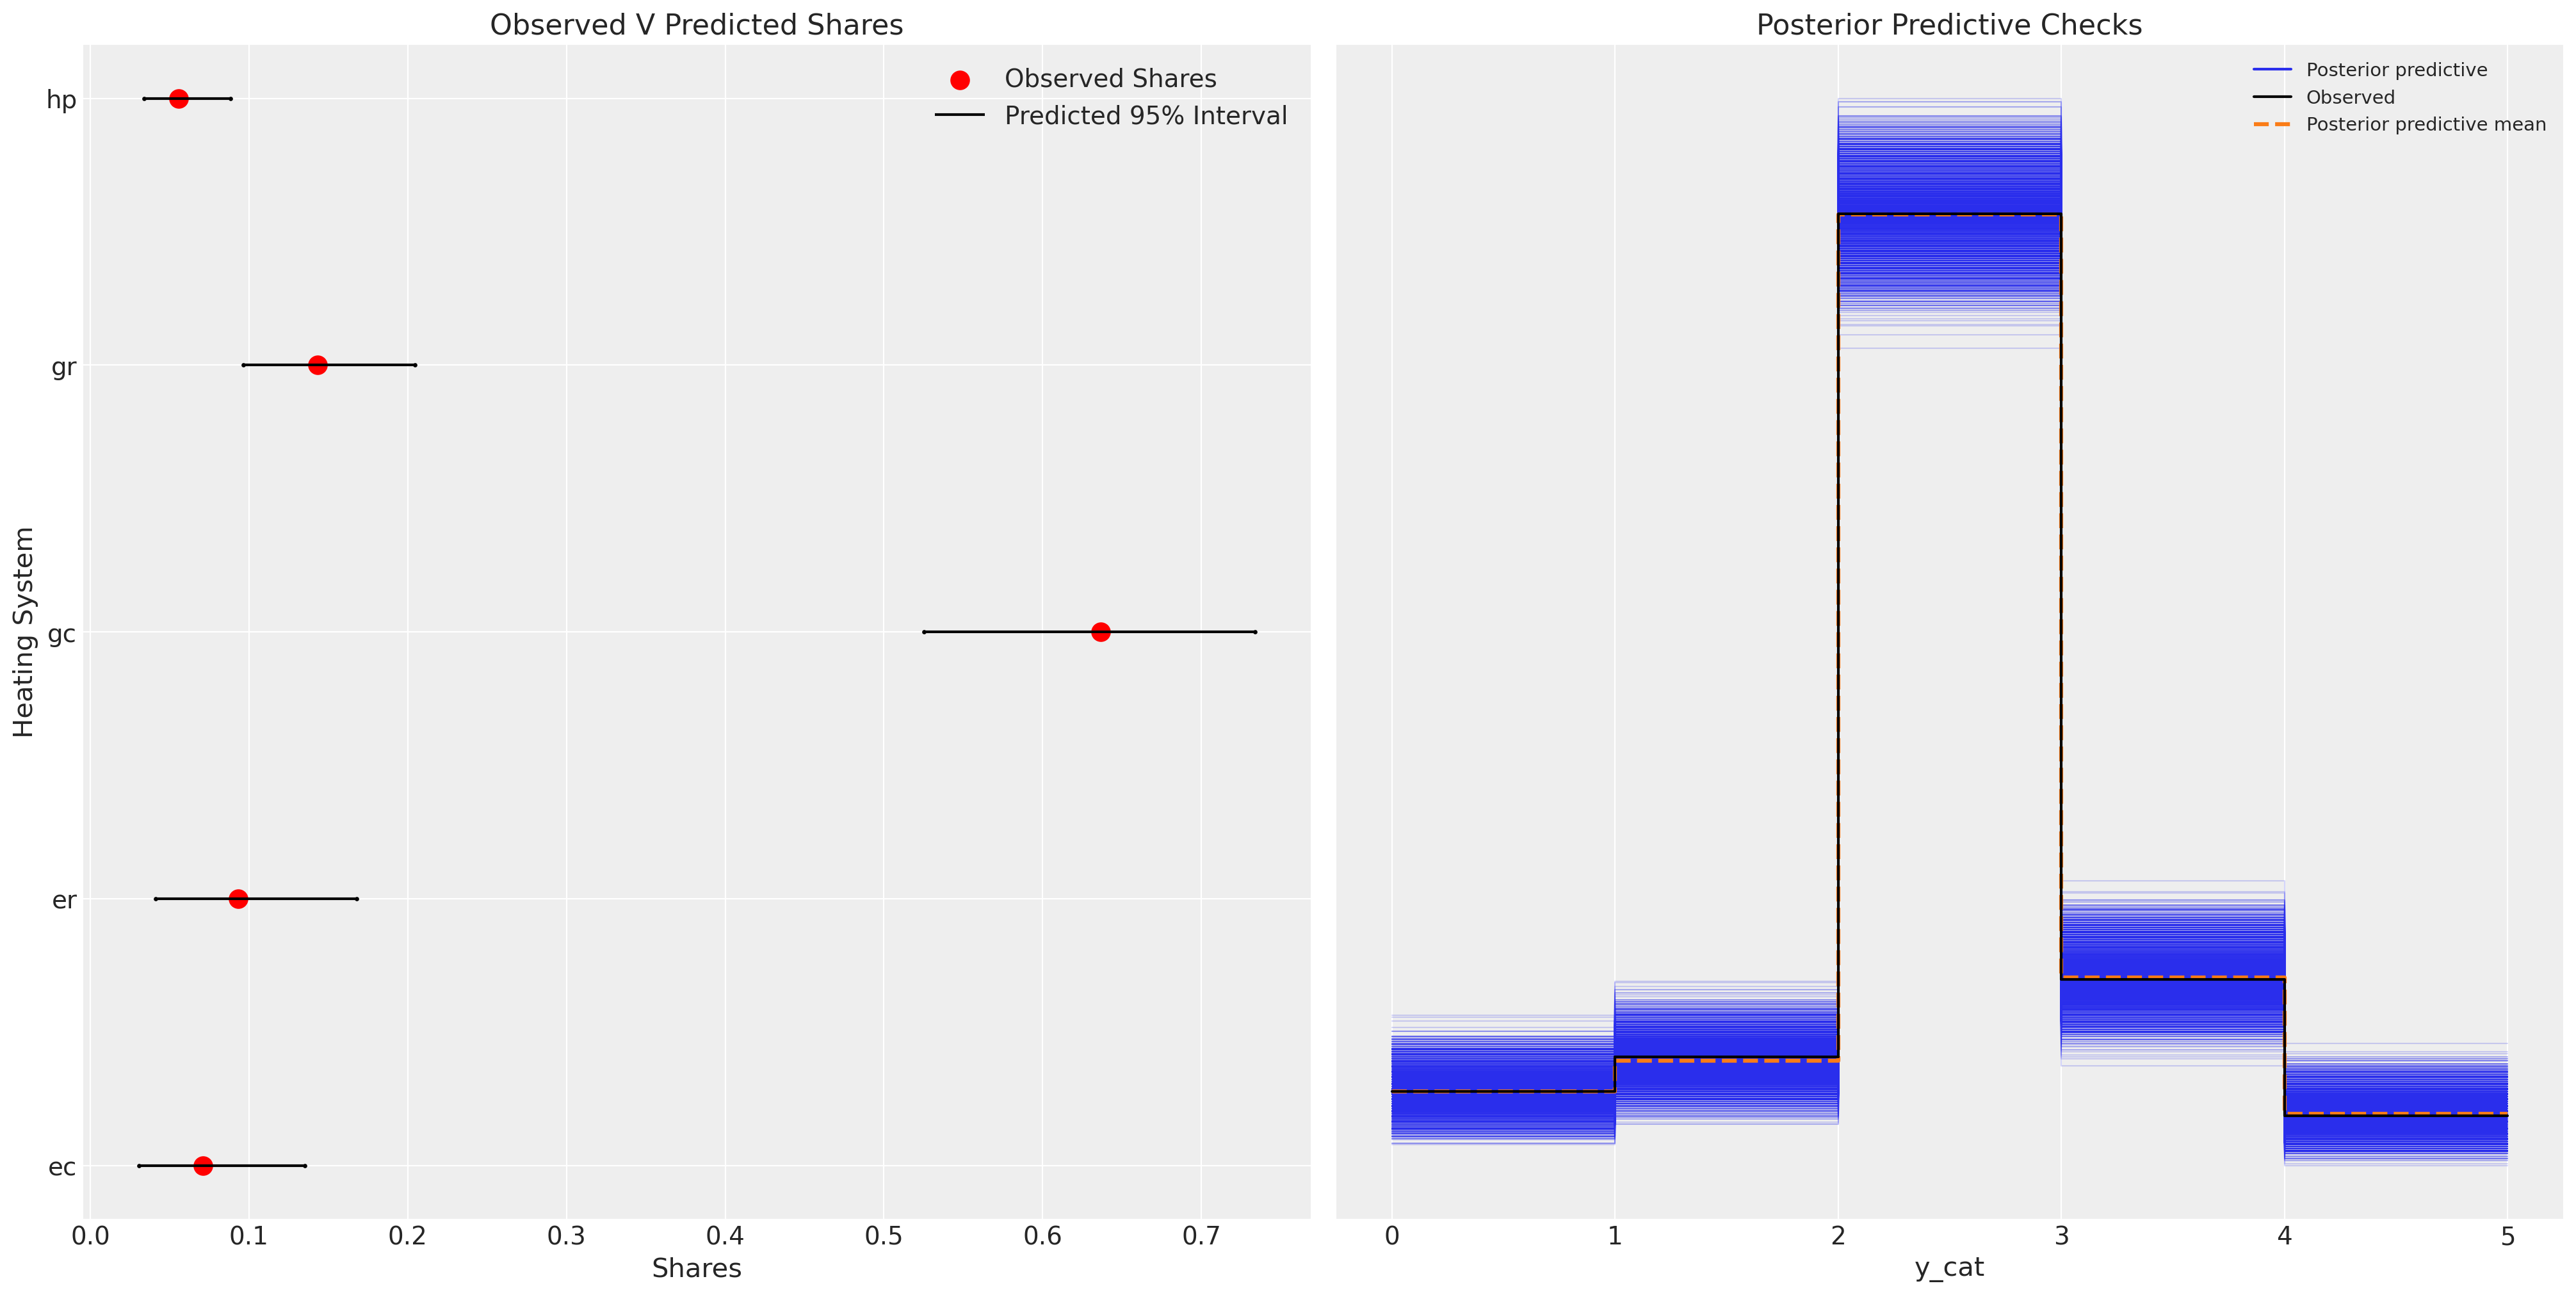

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
ax = axs[0]
counts = wide_heating_df.groupby("depvar")["idcase"].count()
predicted_shares = idata_m3["posterior"]["p"].mean(dim=["chain", "draw", "obs"])
ci_lb = idata_m3["posterior"]["p"].quantile(0.025, dim=["chain", "draw", "obs"])
ci_ub = idata_m3["posterior"]["p"].quantile(0.975, dim=["chain", "draw", "obs"])

ax.scatter(ci_lb, ["ec", "er", "gc", "gr", "hp"], color="k", s=2)
ax.scatter(ci_ub, ["ec", "er", "gc", "gr", "hp"], color="k", s=2)
ax.scatter(
    counts / counts.sum(),
    ["ec", "er", "gc", "gr", "hp"],
    label="Observed Shares",
    color="red",
    s=100,
)
ax.hlines(
    ["ec", "er", "gc", "gr", "hp"], ci_lb, ci_ub, label="Predicted 95% Interval", color="black"
)
ax.legend()
ax.set_title("Observed V Predicted Shares")
az.plot_ppc(idata_m3, ax=axs[1])
axs[1].set_title("Posterior Predictive Checks")
ax.set_xlabel("Shares")
ax.set_ylabel("Heating System");

That extra complexity can be informative, and the degree of relationship amongst the alternative products will inform the substitution patterns under policy changes. Also, note how under this model specification the parameter for `beta_ic` has a expected value of 0. Suggestive perhaps of a resignation towards the reality of installation costs that doesn't change the  utility metric one way or other after a decision to purchase.

In [17]:
az.summary(idata_m3, var_names=["beta_ic", "beta_oc", "alpha", "chol_corr"], round_to=4)

/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/arviz/stats/diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_ic,-0.0016,0.0006,-0.0028,-0.0005,0.0000,0.0000,965.4150,1858.7119,1.0001
beta_oc,-0.0063,0.0014,-0.0088,-0.0035,0.0001,0.0001,279.5321,415.1640,1.0173
alpha[ec],0.1390,0.4889,-0.6647,1.2387,0.0379,0.0268,231.0307,299.2109,1.0194
alpha[er],0.3534,0.5002,-0.2853,1.5779,0.0414,0.0293,194.8276,248.4286,1.0183
alpha[gc],0.3954,0.5681,-0.3446,1.5776,0.0532,0.0380,112.9666,358.4609,1.0290
alpha[gr],-0.9796,0.5950,-1.8111,0.1638,0.0579,0.0410,105.7955,427.4041,1.0316
alpha[hp],-1.3157,0.5856,-2.1852,-0.1067,0.0539,0.0382,141.3095,215.2878,1.0236
"chol_corr[0, 0]",1.0000,0.0000,1.0000,1.0000,0.0000,0.0000,4000.0000,4000.0000,NaN
"chol_corr[0, 1]",0.0324,0.3416,-0.5952,0.6568,0.0087,0.0077,1546.9802,1197.8477,1.0018
"chol_corr[0, 2]",0.0061,0.3520,-0.6189,0.6374,0.0157,0.0111,825.6169,1945.6811,1.0142


In this model we see that the marginal rate of substitution shows that an increase of one dollar for the operating costs is almost 17 times more impactful on the utility calculus than a similar increase in installation costs. Which makes sense in so far as we can expect the installation costs to be a one-off expense we're pretty resigned to. 

In [18]:
post = az.extract(idata_m3)
substitution_rate = post["beta_oc"] / post["beta_ic"]
substitution_rate.mean().item()

4.312409953314165

### Market Inteventions and Predicting Market Share

We can additionally use these kinds of models to predict market share under interventions where we change the price offering.

In [19]:
with model_3:
    # update values of predictors with new 20% price increase in operating costs for electrical options
    pm.set_data({"oc_ec": wide_heating_df["oc.ec"] * 1.2, "oc_er": wide_heating_df["oc.er"] * 1.2})
    # use the updated values and predict outcomes and probabilities:
    idata_new_policy = pm.sample_posterior_predictive(
        idata_m3,
        var_names=["p", "y_cat"],
        return_inferencedata=True,
        predictions=True,
        extend_inferencedata=False,
        random_seed=100,
    )

idata_new_policy

Sampling: [y_cat]


Inference data with groups:
	> predictions
	> predictions_constant_data

In [20]:
# Old Policy Expectations
old = idata_m3["posterior"]["p"].mean(dim=["chain", "draw", "obs"])
old

<xarray.DataArray 'p' (alts_probs: 5)>
array([0.07133772, 0.09128577, 0.63642949, 0.14428672, 0.05666029])
Coordinates:
  * alts_probs  (alts_probs) <U2 'ec' 'er' 'gc' 'gr' 'hp'

In [21]:
# New Policy Expectations
new = idata_new_policy["predictions"]["p"].mean(dim=["chain", "draw", "obs"])
new

<xarray.DataArray 'p' (alts_probs: 5)>
array([0.04381375, 0.05912996, 0.68165693, 0.15463743, 0.06076193])
Coordinates:
  * alts_probs  (alts_probs) <U2 'ec' 'er' 'gc' 'gr' 'hp'

In [22]:
new - old

<xarray.DataArray 'p' (alts_probs: 5)>
array([-0.02752397, -0.03215581,  0.04522743,  0.01035071,  0.00410164])
Coordinates:
  * alts_probs  (alts_probs) <U2 'ec' 'er' 'gc' 'gr' 'hp'

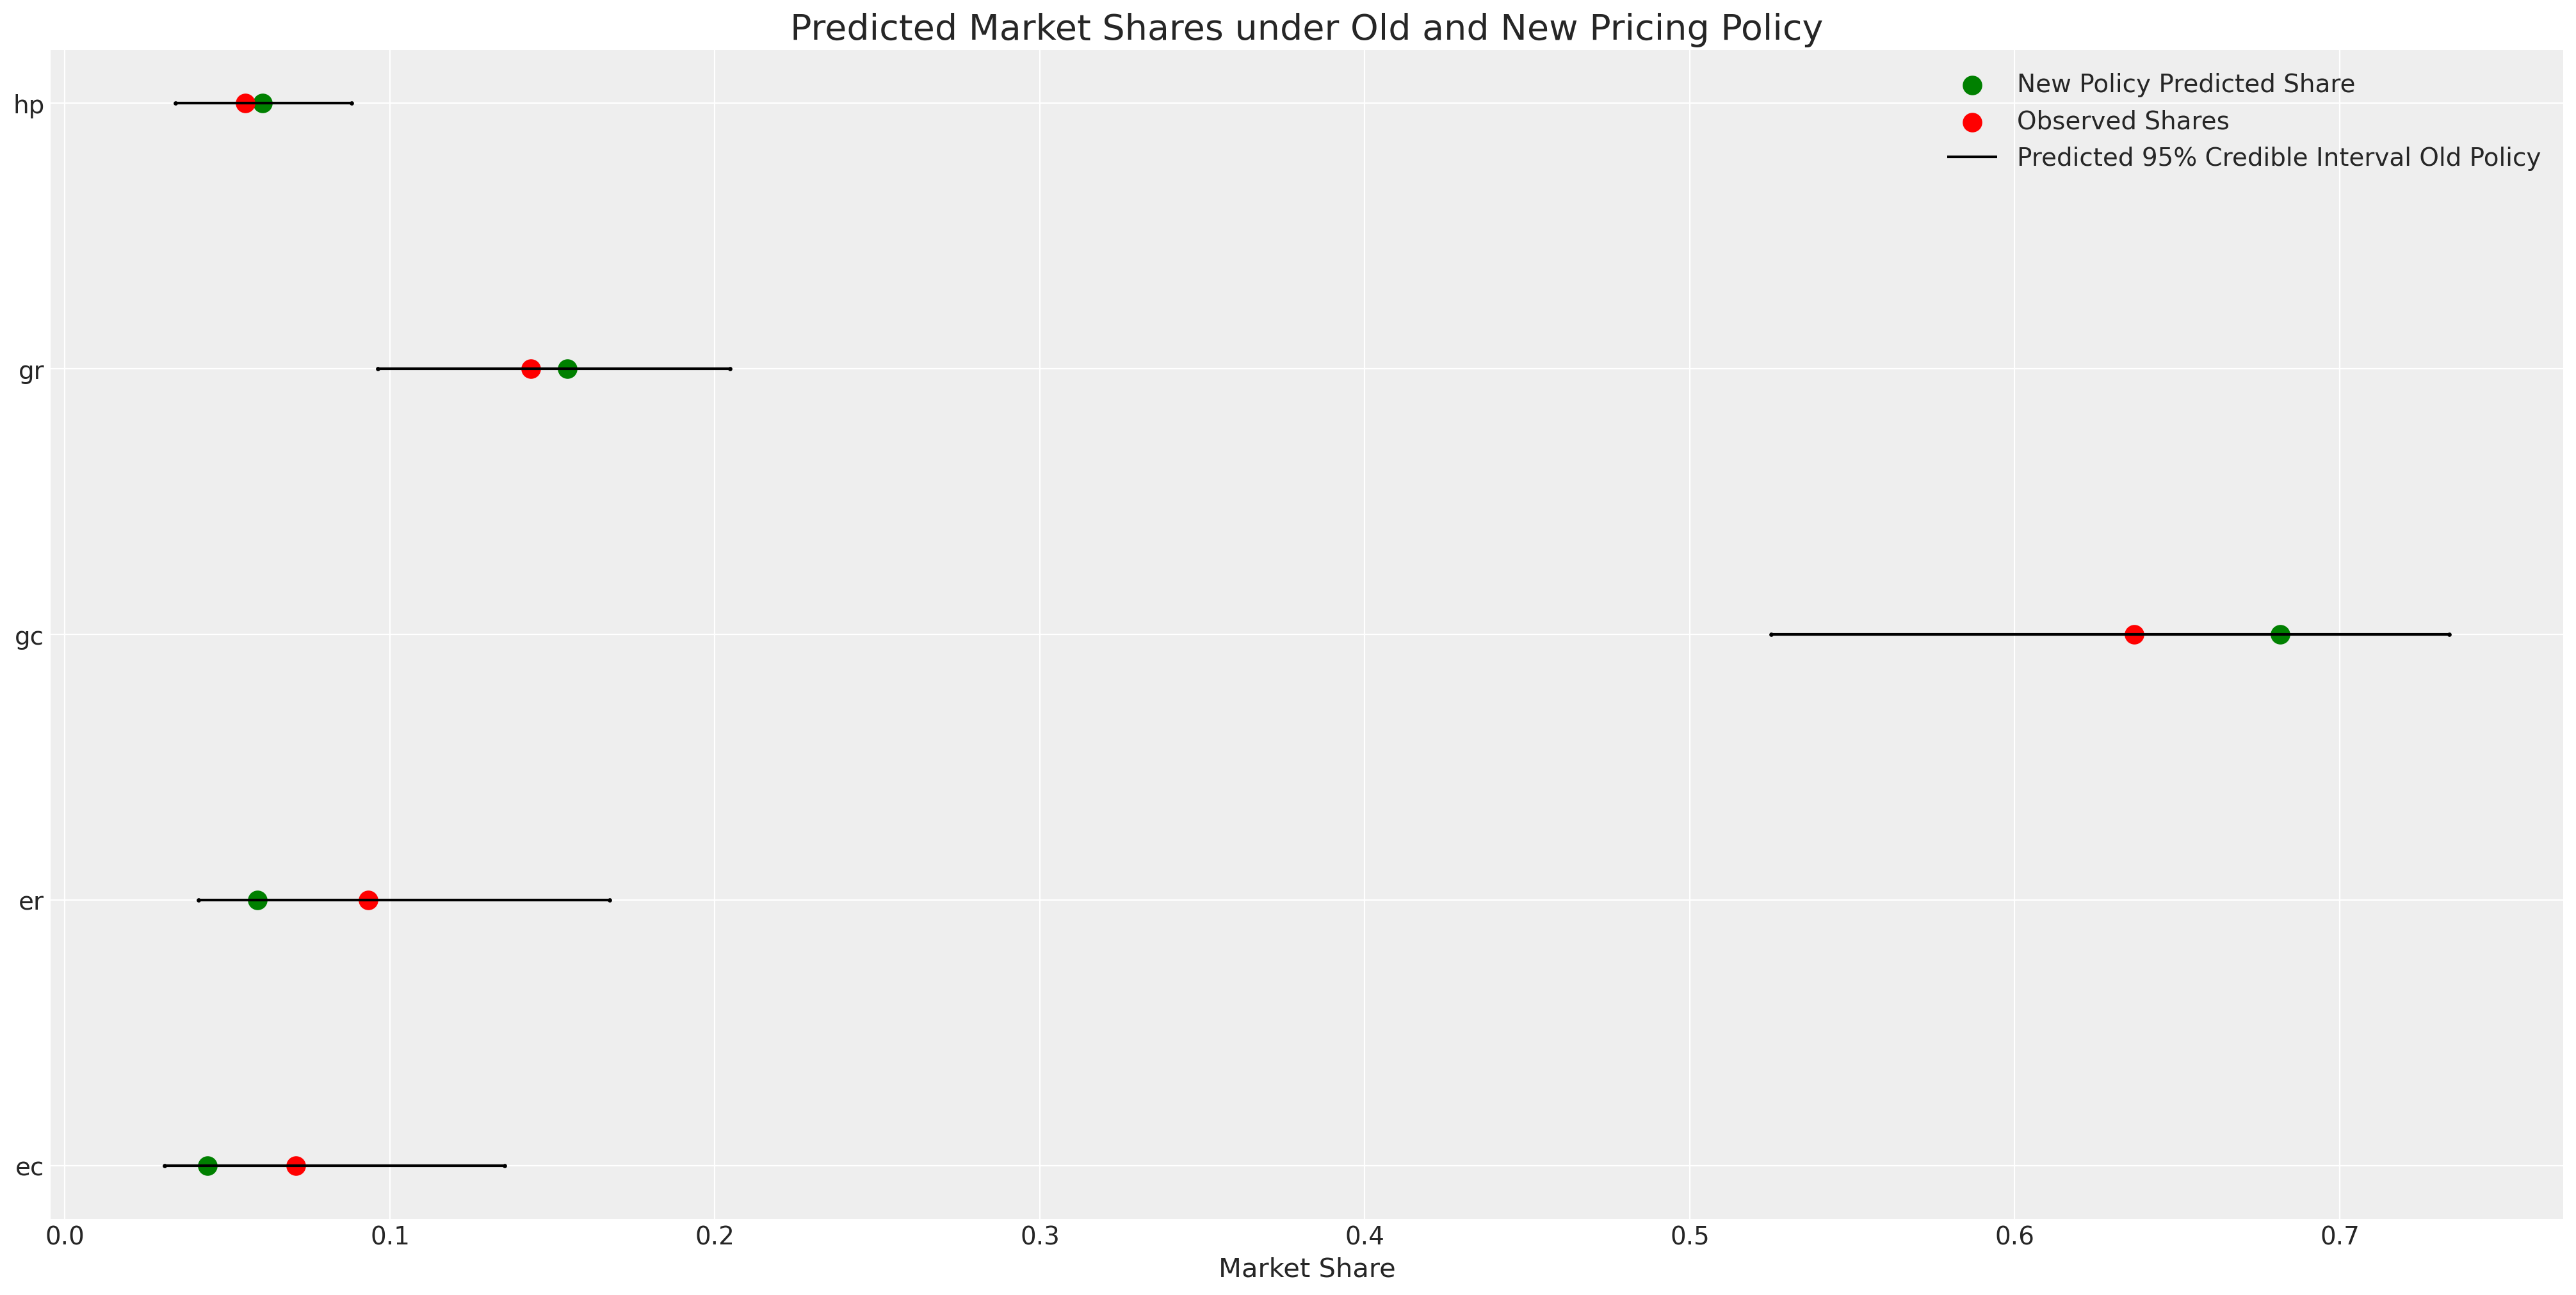

In [23]:
fig, ax = plt.subplots(1, figsize=(20, 10))
counts = wide_heating_df.groupby("depvar")["idcase"].count()
new_predictions = idata_new_policy["predictions"]["p"].mean(dim=["chain", "draw", "obs"]).values
ci_lb = idata_m3["posterior"]["p"].quantile(0.025, dim=["chain", "draw", "obs"])
ci_ub = idata_m3["posterior"]["p"].quantile(0.975, dim=["chain", "draw", "obs"])
ax.scatter(ci_lb, ["ec", "er", "gc", "gr", "hp"], color="k", s=2)
ax.scatter(ci_ub, ["ec", "er", "gc", "gr", "hp"], color="k", s=2)
ax.scatter(
    new_predictions,
    ["ec", "er", "gc", "gr", "hp"],
    color="green",
    label="New Policy Predicted Share",
    s=100,
)
ax.scatter(
    counts / counts.sum(),
    ["ec", "er", "gc", "gr", "hp"],
    label="Observed Shares",
    color="red",
    s=100,
)
ax.hlines(
    ["ec", "er", "gc", "gr", "hp"],
    ci_lb,
    ci_ub,
    label="Predicted 95% Credible Interval Old Policy",
    color="black",
)
ax.set_title("Predicted Market Shares under Old and New Pricing Policy", fontsize=20)
ax.set_xlabel("Market Share")
ax.legend();

Here we can, as expected, see that a rise in the operating costs of the electrical options has a negative impact on their predicted market share.  

### Compare Models

We'll now evaluate all three model fits on their predictive performance. Predictive performance on the original data is a good benchmark that the model has appropriately captured the data generating process. But it is not (as we've seen) the only feature of interest in these models. These models are sensetive to our theoretical beliefs about the agents making the decisions, the view of the decision process and the elements of the choice scenario.

In [24]:
compare = az.compare({"m1": idata_m1, "m2": idata_m2, "m3": idata_m3})
compare

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m3,0,-1014.070339,5.636640,0.000000,1.000000e+00,27.994286,0.000000,False,log
m2,1,-1014.343946,5.398733,0.273607,1.067993e-10,27.880217,0.733146,False,log
m1,2,-1097.230815,1.999354,83.160476,0.000000e+00,26.259507,12.010909,False,log


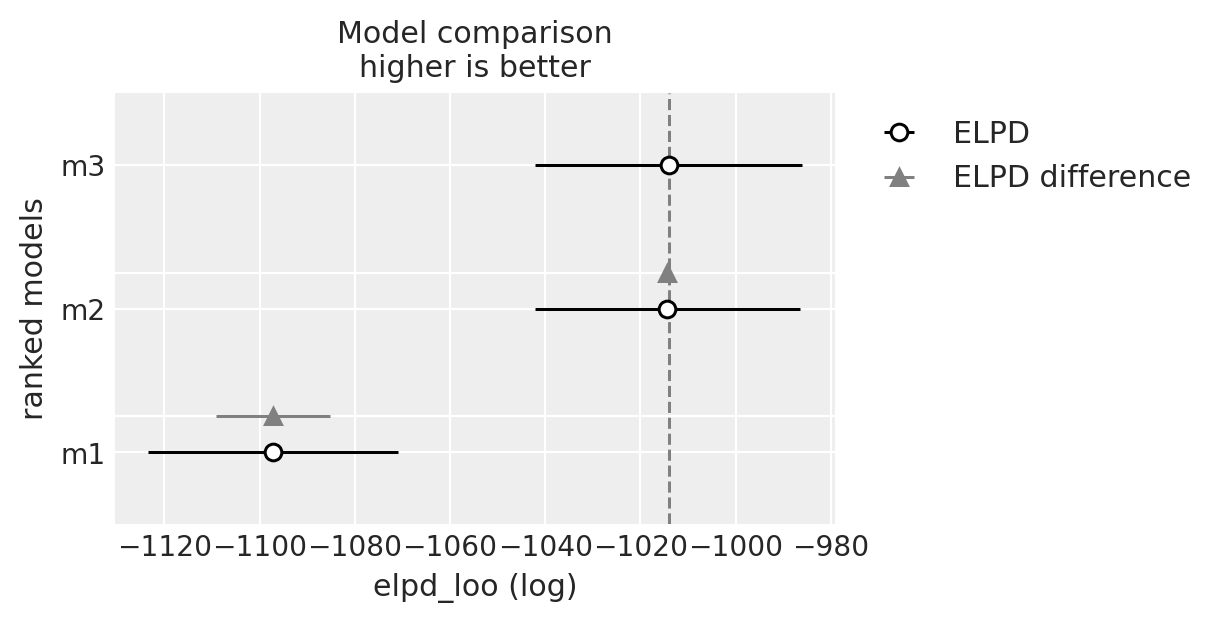

In [25]:
az.plot_compare(compare);

## Choosing Crackers over Repeated Choices: Mixed Logit Model

Moving to another example, we see a choice scenario where the same individual has been repeatedly polled on their choice of crackers among alternatives. This affords us the opportunity to evaluate the preferences of individuals by adding in coefficients for individuals for each product. 

In [26]:
try:
    c_df = pd.read_csv("../data/cracker_choice_short.csv")
except:
    c_df = pd.read_csv(pm.get_data("cracker_choice_short.csv"))
columns = [c for c in c_df.columns if c != "Unnamed: 0"]
c_df[columns]

,personId,disp.sunshine,disp.keebler,disp.nabisco,disp.private,feat.sunshine,feat.keebler,feat.nabisco,feat.private,price.sunshine,price.keebler,price.nabisco,price.private,choice,lastChoice,personChoiceId,choiceId
0,1,0,0,0,0,0,0,0,0,0.99,1.09,0.99,0.71,nabisco,nabisco,1,1
1,1,1,0,0,0,0,0,0,0,0.49,1.09,1.09,0.78,sunshine,nabisco,2,2
2,1,0,0,0,0,0,0,0,0,1.03,1.09,0.89,0.78,nabisco,sunshine,3,3
3,1,0,0,0,0,0,0,0,0,1.09,1.09,1.19,0.64,nabisco,nabisco,4,4
4,1,0,0,0,0,0,0,0,0,0.89,1.09,1.19,0.84,nabisco,nabisco,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3151,136,0,0,0,0,0,0,0,0,1.09,1.19,0.99,0.55,private,private,9,3152
3152,136,0,0,0,1,0,0,0,0,0.78,1.35,1.04,0.65,private,private,10,3153
3153,136,0,0,0,0,0,0,0,0,1.09,1.17,1.29,0.59,private,private,11,3154
3154,136,0,0,0,0,0,0,0,0,1.09,1.22,1.29,0.59,private,private,12,3155


In [27]:
c_df.groupby("personId")[["choiceId"]].count().T

personId,1,2,3,4,5,6,7,8,9,10,...,127,128,129,130,131,132,133,134,135,136
choiceId,15,15,13,28,13,27,16,25,18,40,...,17,25,31,31,29,21,26,13,14,13


The presence of repeated choice over time complicates the issue. We now have to contend with issues of personal taste and the evolving or dynamic effects of pricing in a competitive environment. Plotting the simple linear and polynomial fits for each person's successive exposure to the brand price, seems to suggest that (a) pricing differentiates the product offering and (b) pricing evolves over time. 

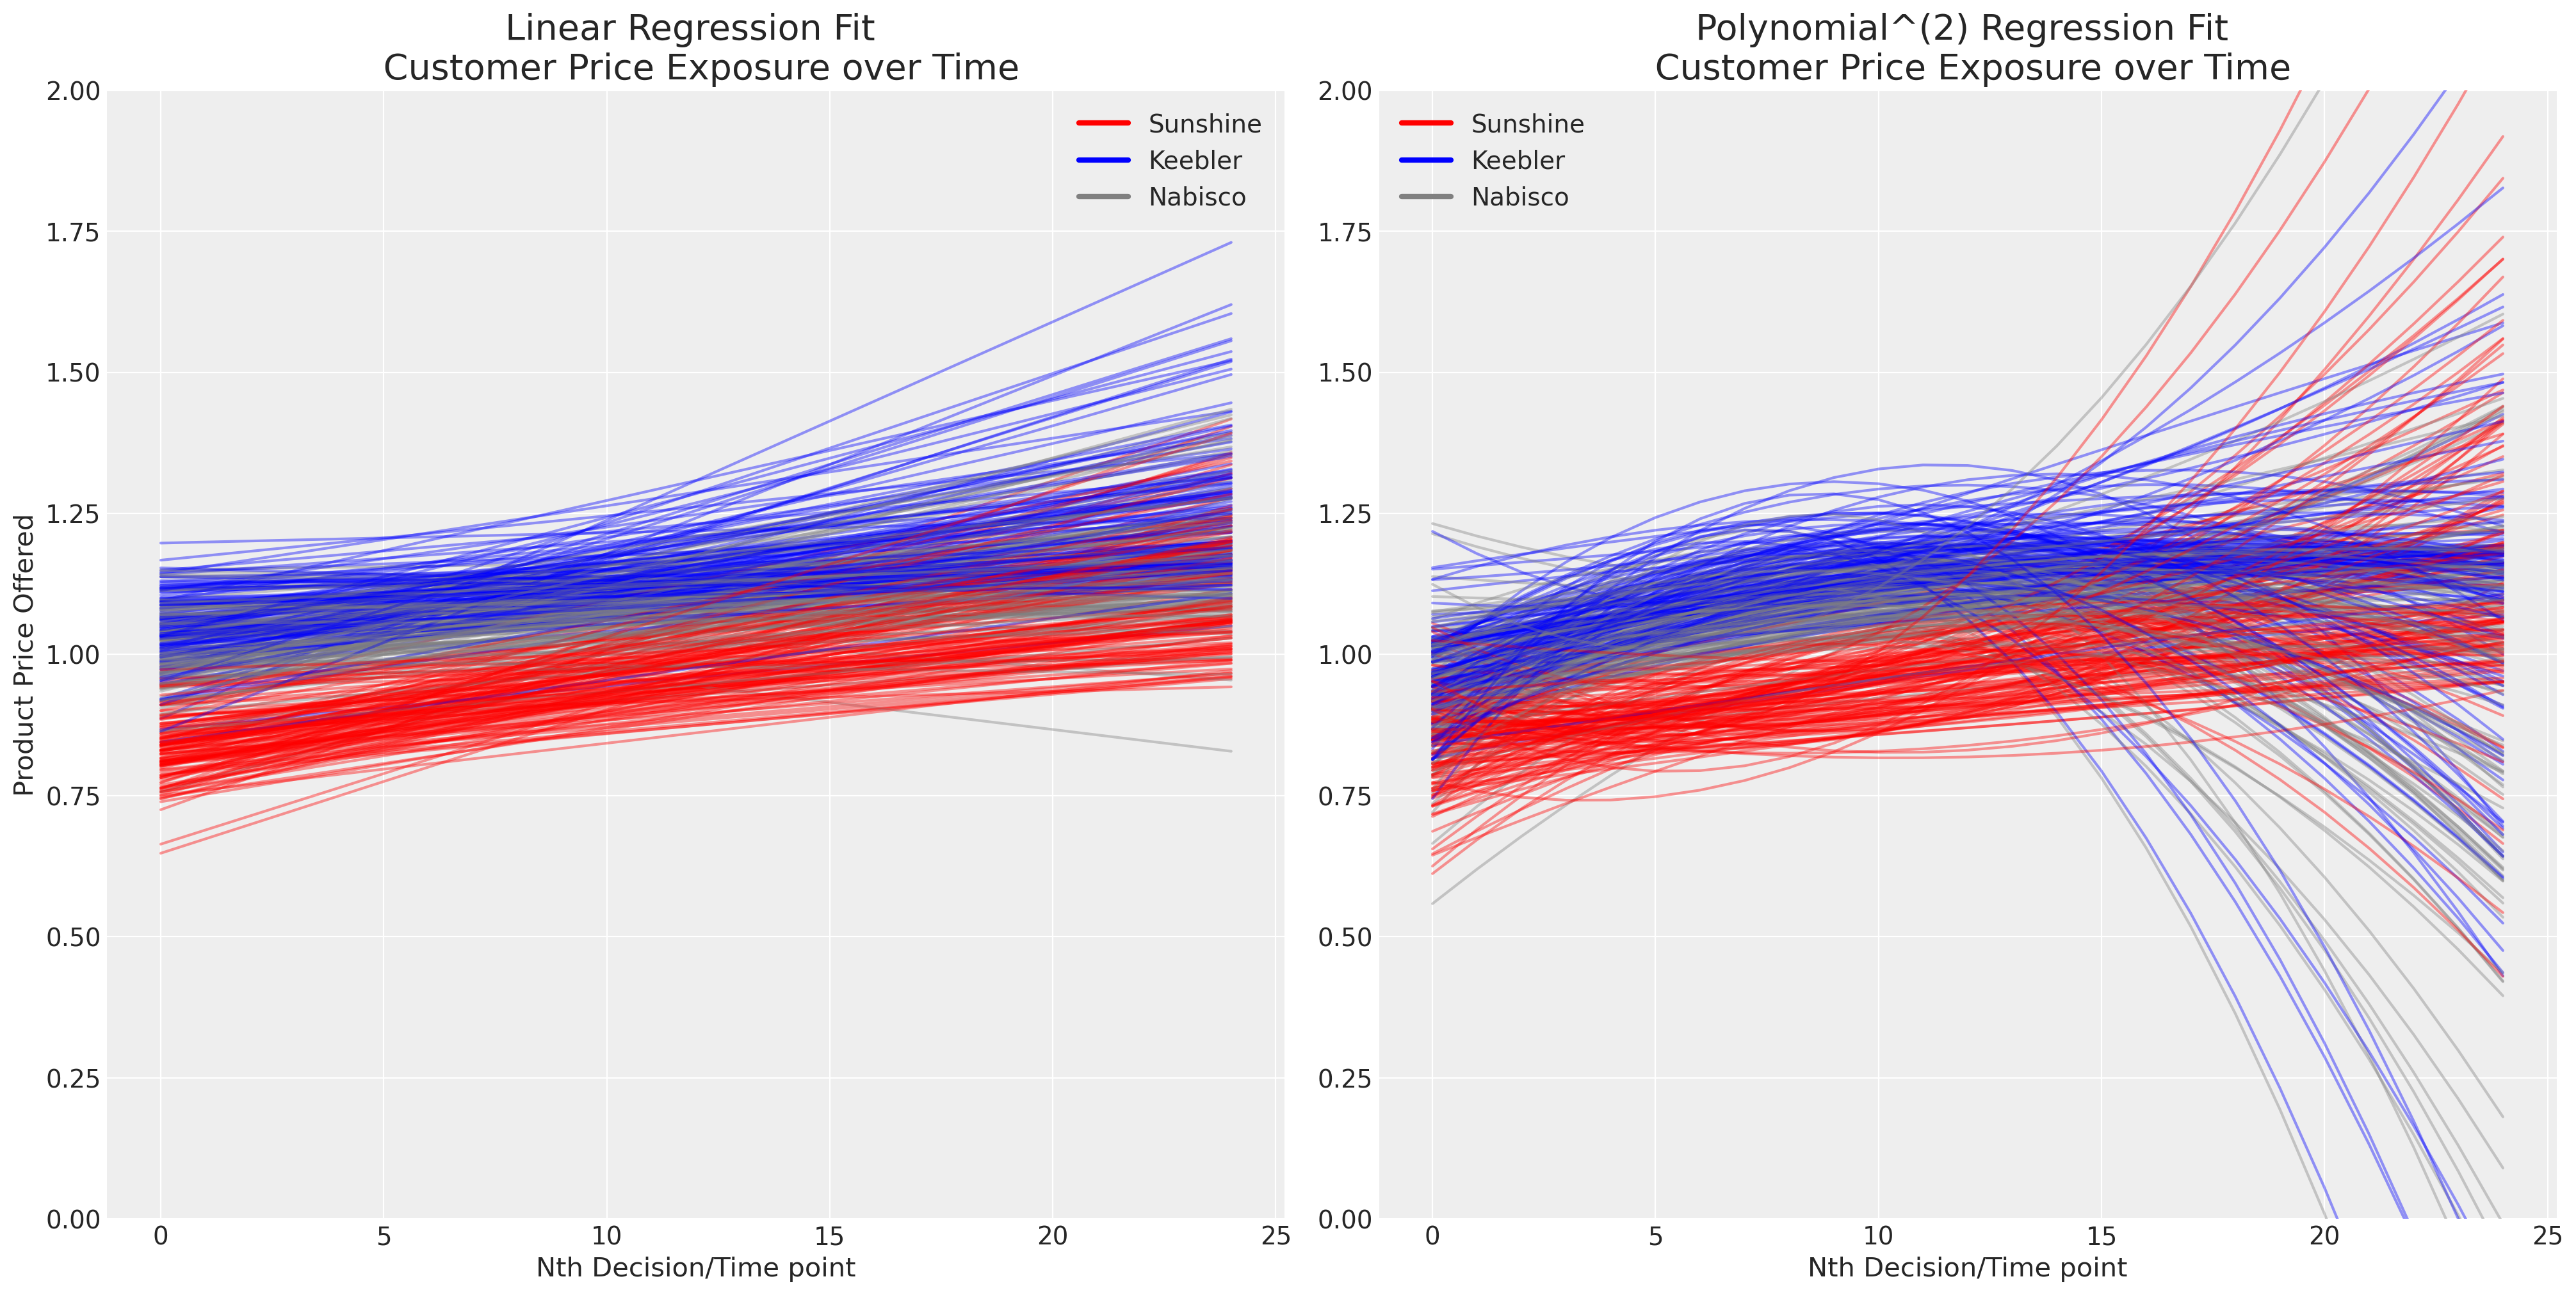

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs = axs.flatten()
map_color = {"nabisco": "red", "keebler": "blue", "sunshine": "purple", "private": "orange"}


for i in c_df["personId"].unique():
    temp = c_df[c_df["personId"] == i].copy(deep=True)
    temp["color"] = temp["choice"].map(map_color)
    predict = np.poly1d(np.polyfit(temp["personChoiceId"], temp["price.sunshine"], deg=1))
    axs[0].plot(predict(range(25)), color="red", label="Sunshine", alpha=0.4)
    predict = np.poly1d(np.polyfit(temp["personChoiceId"], temp["price.keebler"], deg=1))
    axs[0].plot(predict(range(25)), color="blue", label="Keebler", alpha=0.4)
    predict = np.poly1d(np.polyfit(temp["personChoiceId"], temp["price.nabisco"], deg=1))
    axs[0].plot(predict(range(25)), color="grey", label="Nabisco", alpha=0.4)

    predict = np.poly1d(np.polyfit(temp["personChoiceId"], temp["price.sunshine"], deg=2))
    axs[1].plot(predict(range(25)), color="red", label="Sunshine", alpha=0.4)
    predict = np.poly1d(np.polyfit(temp["personChoiceId"], temp["price.keebler"], deg=2))
    axs[1].plot(predict(range(25)), color="blue", label="Keebler", alpha=0.4)
    predict = np.poly1d(np.polyfit(temp["personChoiceId"], temp["price.nabisco"], deg=2))
    axs[1].plot(predict(range(25)), color="grey", label="Nabisco", alpha=0.4)

axs[0].set_title("Linear Regression Fit \n Customer Price Exposure over Time", fontsize=20)
axs[1].set_title("Polynomial^(2) Regression Fit \n Customer Price Exposure over Time", fontsize=20)
axs[0].set_xlabel("Nth Decision/Time point")
axs[1].set_xlabel("Nth Decision/Time point")
axs[0].set_ylabel("Product Price Offered")
axs[1].set_ylim(0, 2)
axs[0].set_ylim(0, 2)

colors = ["red", "blue", "grey"]
lines = [Line2D([0], [0], color=c, linewidth=3, linestyle="-") for c in colors]
labels = ["Sunshine", "Keebler", "Nabisco"]
axs[0].legend(lines, labels)
axs[1].legend(lines, labels);

We'll model now how individual taste enters into discrete choice problems, but ignore the complexities of the time-dimension or the endogenity of price in the system. There are adaptions of the basic discrete choice model that are designed to address each of these complications. We'll leave the temporal dynamics as a suggested exercise for the reader. 

Sampling: [alpha, beta_disp, beta_feat, beta_individual, beta_price, y_cat]
/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/pymc/sampling/mcmc.py:243: UserWarning: Use of external NUTS sampler is still experimental
  warnings.warn("Use of external NUTS sampler is still experimental", UserWarning)


Compiling...
Compilation time =  0:00:01.425976
Sampling...


  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Sampling time =  0:00:12.028729
Transforming variables...
Transformation time =  0:00:01.427529
Computing Log Likelihood...


Sampling: [y_cat]


Log Likelihood time =  0:00:01.775443


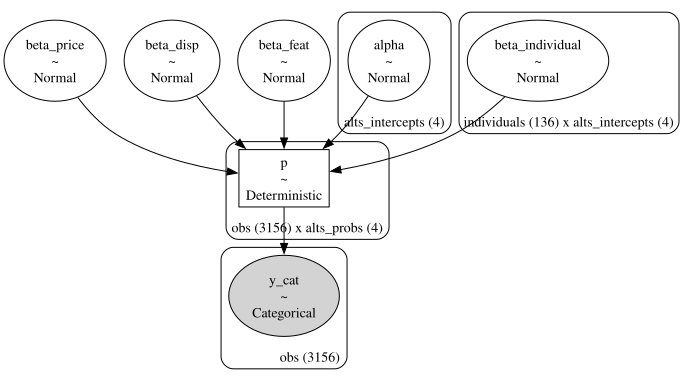

In [29]:
N = c_df.shape[0]
map = {"sunshine": 0, "keebler": 1, "nabisco": 2, "private": 3}
c_df["choice_encoded"] = c_df["choice"].map(map)
observed = c_df["choice_encoded"].values
person_indx, uniques = pd.factorize(c_df["personId"])

coords = {
    "alts_intercepts": ["sunshine", "keebler", "nabisco", "private"],
    "alts_probs": ["sunshine", "keebler", "nabisco", "private"],
    "individuals": uniques,
    "obs": range(N),
}
with pm.Model(coords=coords) as model_4:
    beta_feat = pm.Normal("beta_feat", 0, 1)
    beta_disp = pm.Normal("beta_disp", 0, 1)
    beta_price = pm.Normal("beta_price", 0, 1)
    alphas = pm.Normal("alpha", 0, 1, dims="alts_intercepts")
    ## Hierarchical parameters for individual taste
    beta_individual = pm.Normal("beta_individual", 0, 0.1, dims=("individuals", "alts_intercepts"))

    u0 = (
        (alphas[0] + beta_individual[person_indx, 0])
        + beta_disp * c_df["disp.sunshine"]
        + beta_feat * c_df["feat.sunshine"]
        + beta_price * c_df["price.sunshine"]
    )
    u1 = (
        (alphas[1] + beta_individual[person_indx, 1])
        + beta_disp * c_df["disp.keebler"]
        + beta_feat * c_df["feat.keebler"]
        + beta_price * c_df["price.keebler"]
    )
    u2 = (
        (alphas[2] + beta_individual[person_indx, 2])
        + beta_disp * c_df["disp.nabisco"]
        + beta_feat * c_df["feat.nabisco"]
        + beta_price * c_df["price.nabisco"]
    )
    u3 = (
        (0 + beta_individual[person_indx, 2])
        + beta_disp * c_df["disp.private"]
        + beta_feat * c_df["feat.private"]
        + beta_price * c_df["price.private"]
    )
    s = pm.math.stack([u0, u1, u2, u3]).T

    ## Apply Softmax Transform
    p_ = pm.Deterministic("p", pm.math.softmax(s, axis=1), dims=("obs", "alts_probs"))

    ## Likelihood
    choice_obs = pm.Categorical("y_cat", p=p_, observed=observed, dims="obs")

    idata_m4 = pm.sample_prior_predictive()
    idata_m4.extend(
        pm.sample(nuts_sampler="numpyro", idata_kwargs={"log_likelihood": True}, random_seed=103)
    )
    idata_m4.extend(pm.sample_posterior_predictive(idata_m4))


pm.model_to_graphviz(model_4)

In [30]:
az.summary(idata_m4, var_names=["beta_disp", "beta_feat", "beta_price", "alpha"]).head(6)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta_disp,0.104,0.063,-0.016,0.216,0.001,0.001,5853.0,3169.0,1.00
beta_feat,0.505,0.095,0.325,0.678,0.001,0.001,4476.0,2663.0,1.00
beta_price,-2.977,0.209,-3.395,-2.607,0.005,0.004,1765.0,2557.0,1.00
alpha[sunshine],-0.708,0.093,-0.883,-0.531,0.002,0.001,2493.0,2960.0,1.00
alpha[keebler],-0.231,0.120,-0.449,0.000,0.003,0.002,1974.0,2635.0,1.00
alpha[nabisco],1.723,0.101,1.538,1.920,0.002,0.002,1752.0,2653.0,1.01


What have we learned? We've imposed a negative slope on the price coefficient but given it a wide prior. We can see that the data is sufficient to have narrowed the likely range of the coefficient considerably. 

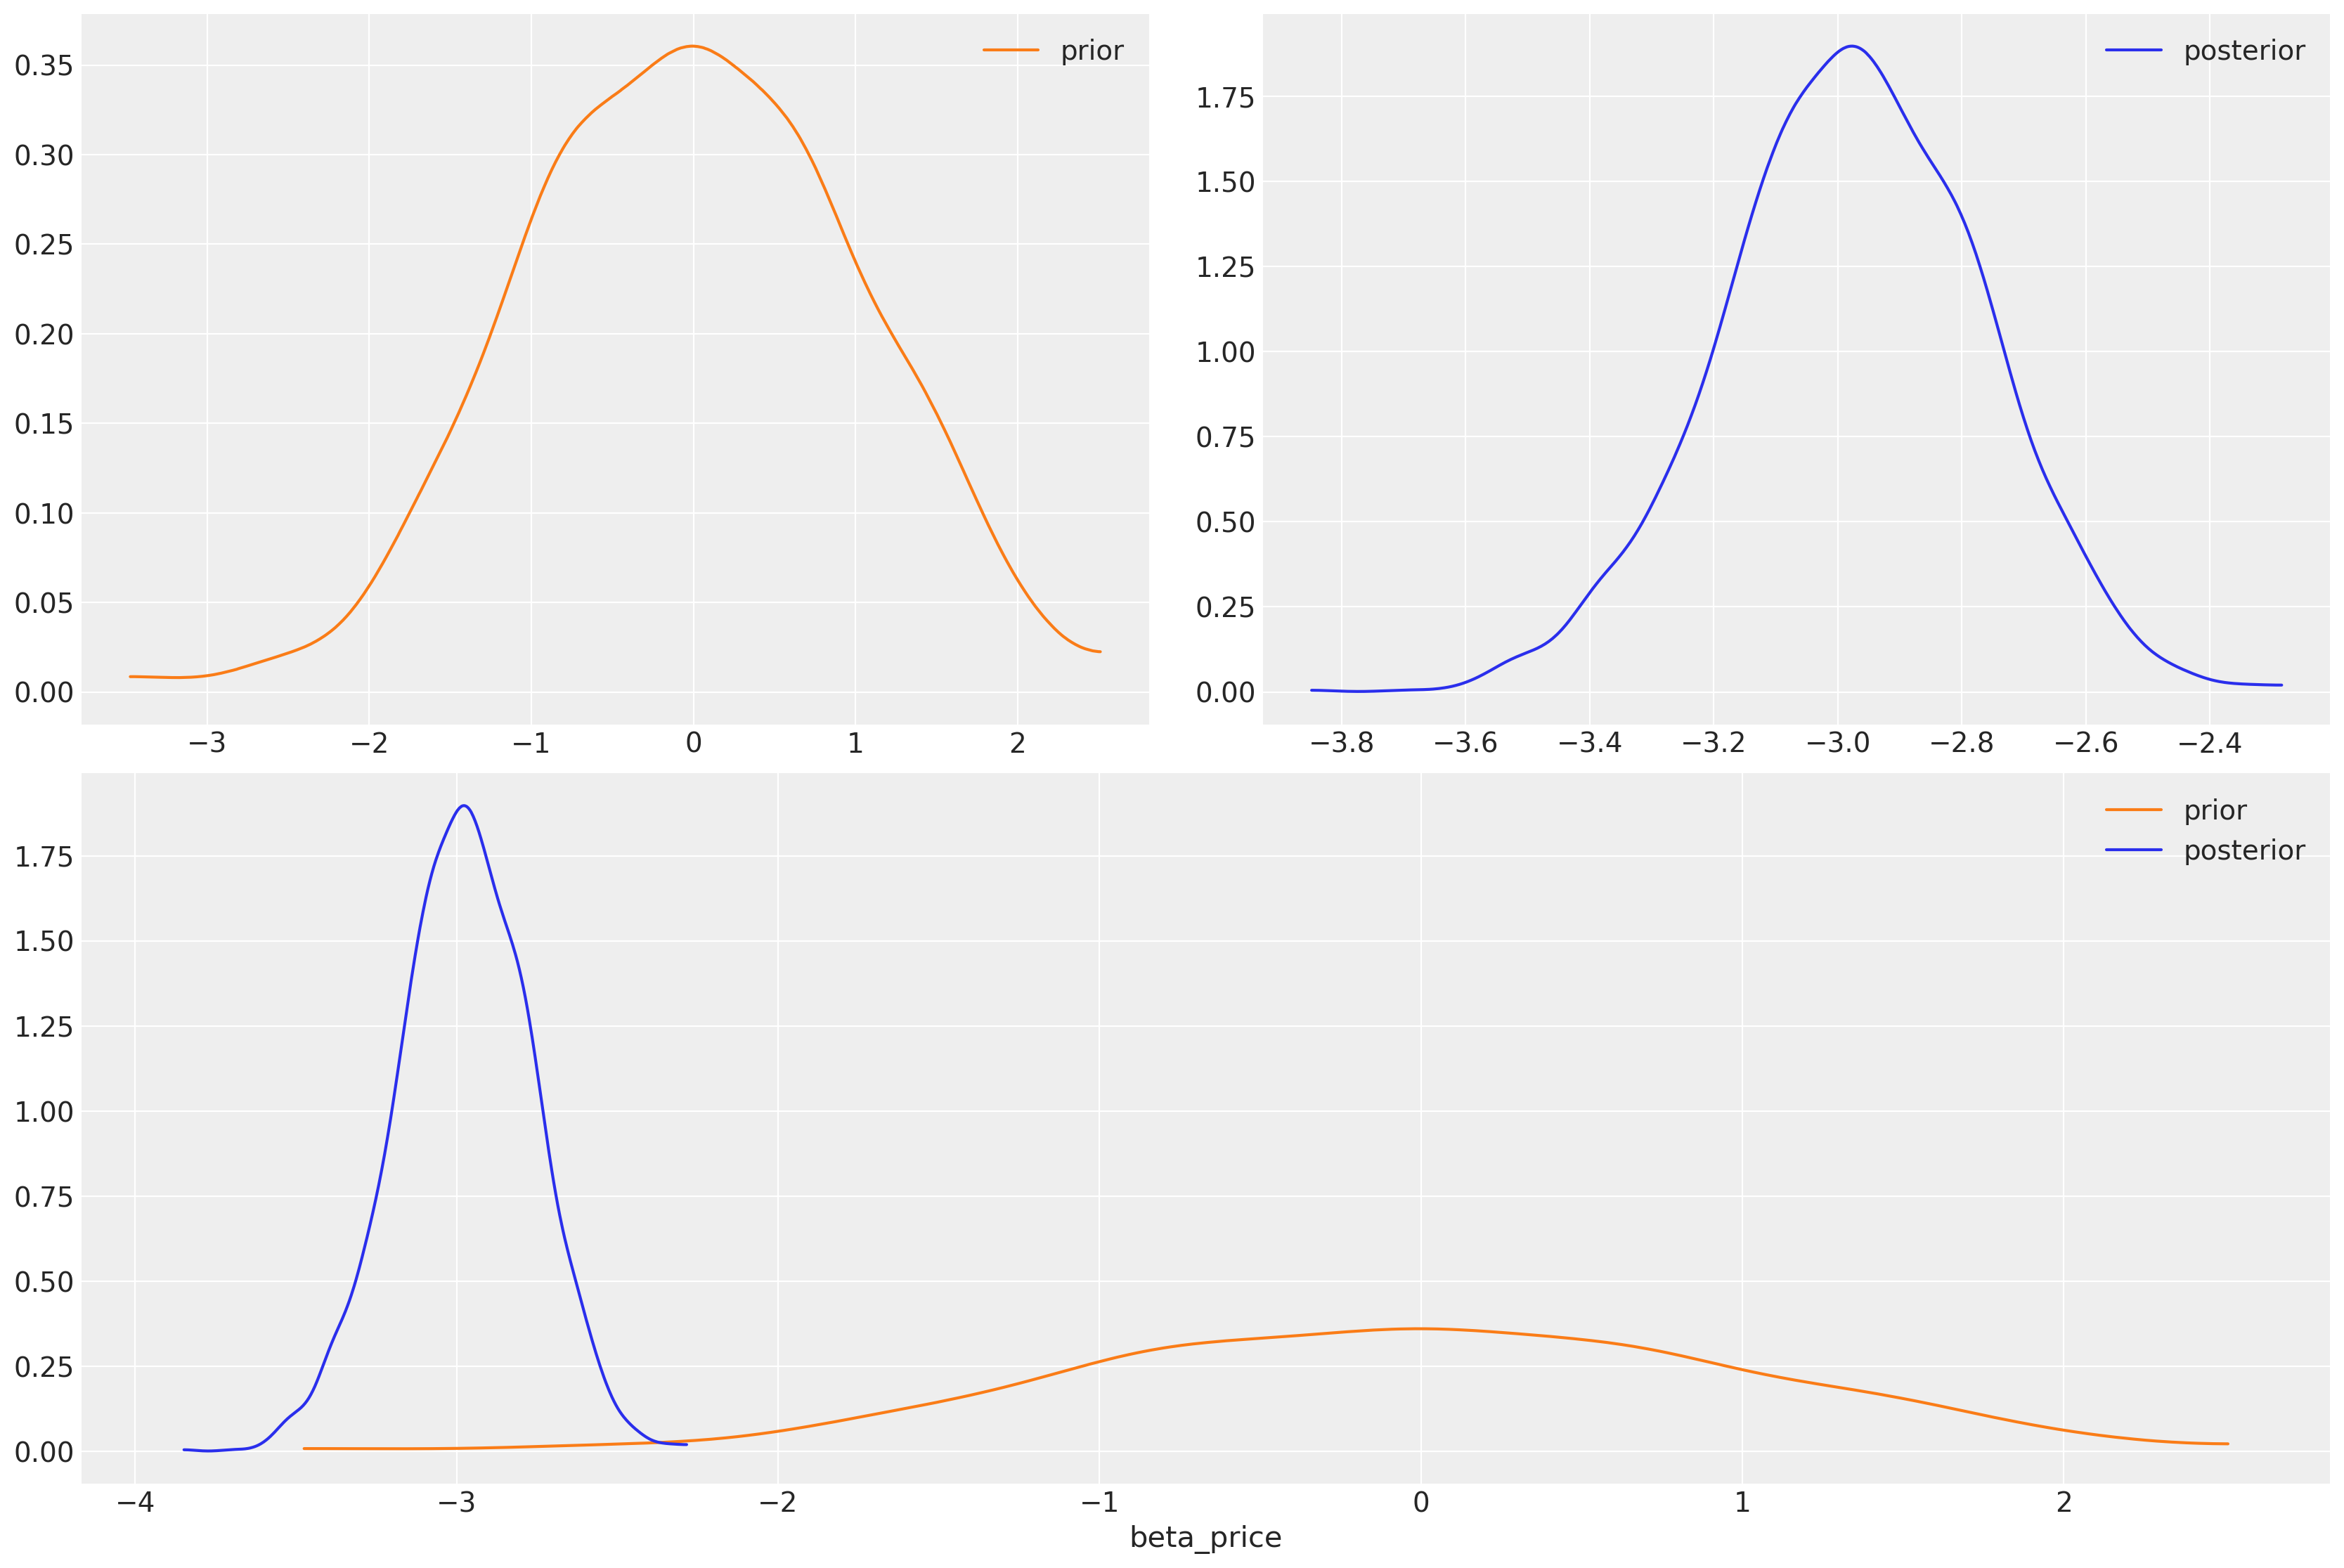

In [31]:
az.plot_dist_comparison(idata_m4, var_names=["beta_price"]);

We have recovered a strongly negative estimate on the price effect in line with the basic theory of rational choice. The effect of price should have a negative impact on utility. The flexibility of priors here is key for incorporating theoretical knowledge about the process involved in choice. Priors are important for building a better picture of the decision making process and we'd be foolish to ignore their value in this setting. 

/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/arviz/plots/ppcplot.py:267: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten_pp = list(predictive_dataset.dims.keys())
/Users/nathanielforde/mambaforge/envs/pymc_examples_new/lib/python3.9/site-packages/arviz/plots/ppcplot.py:271: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  flatten = list(observed_data.dims.keys())


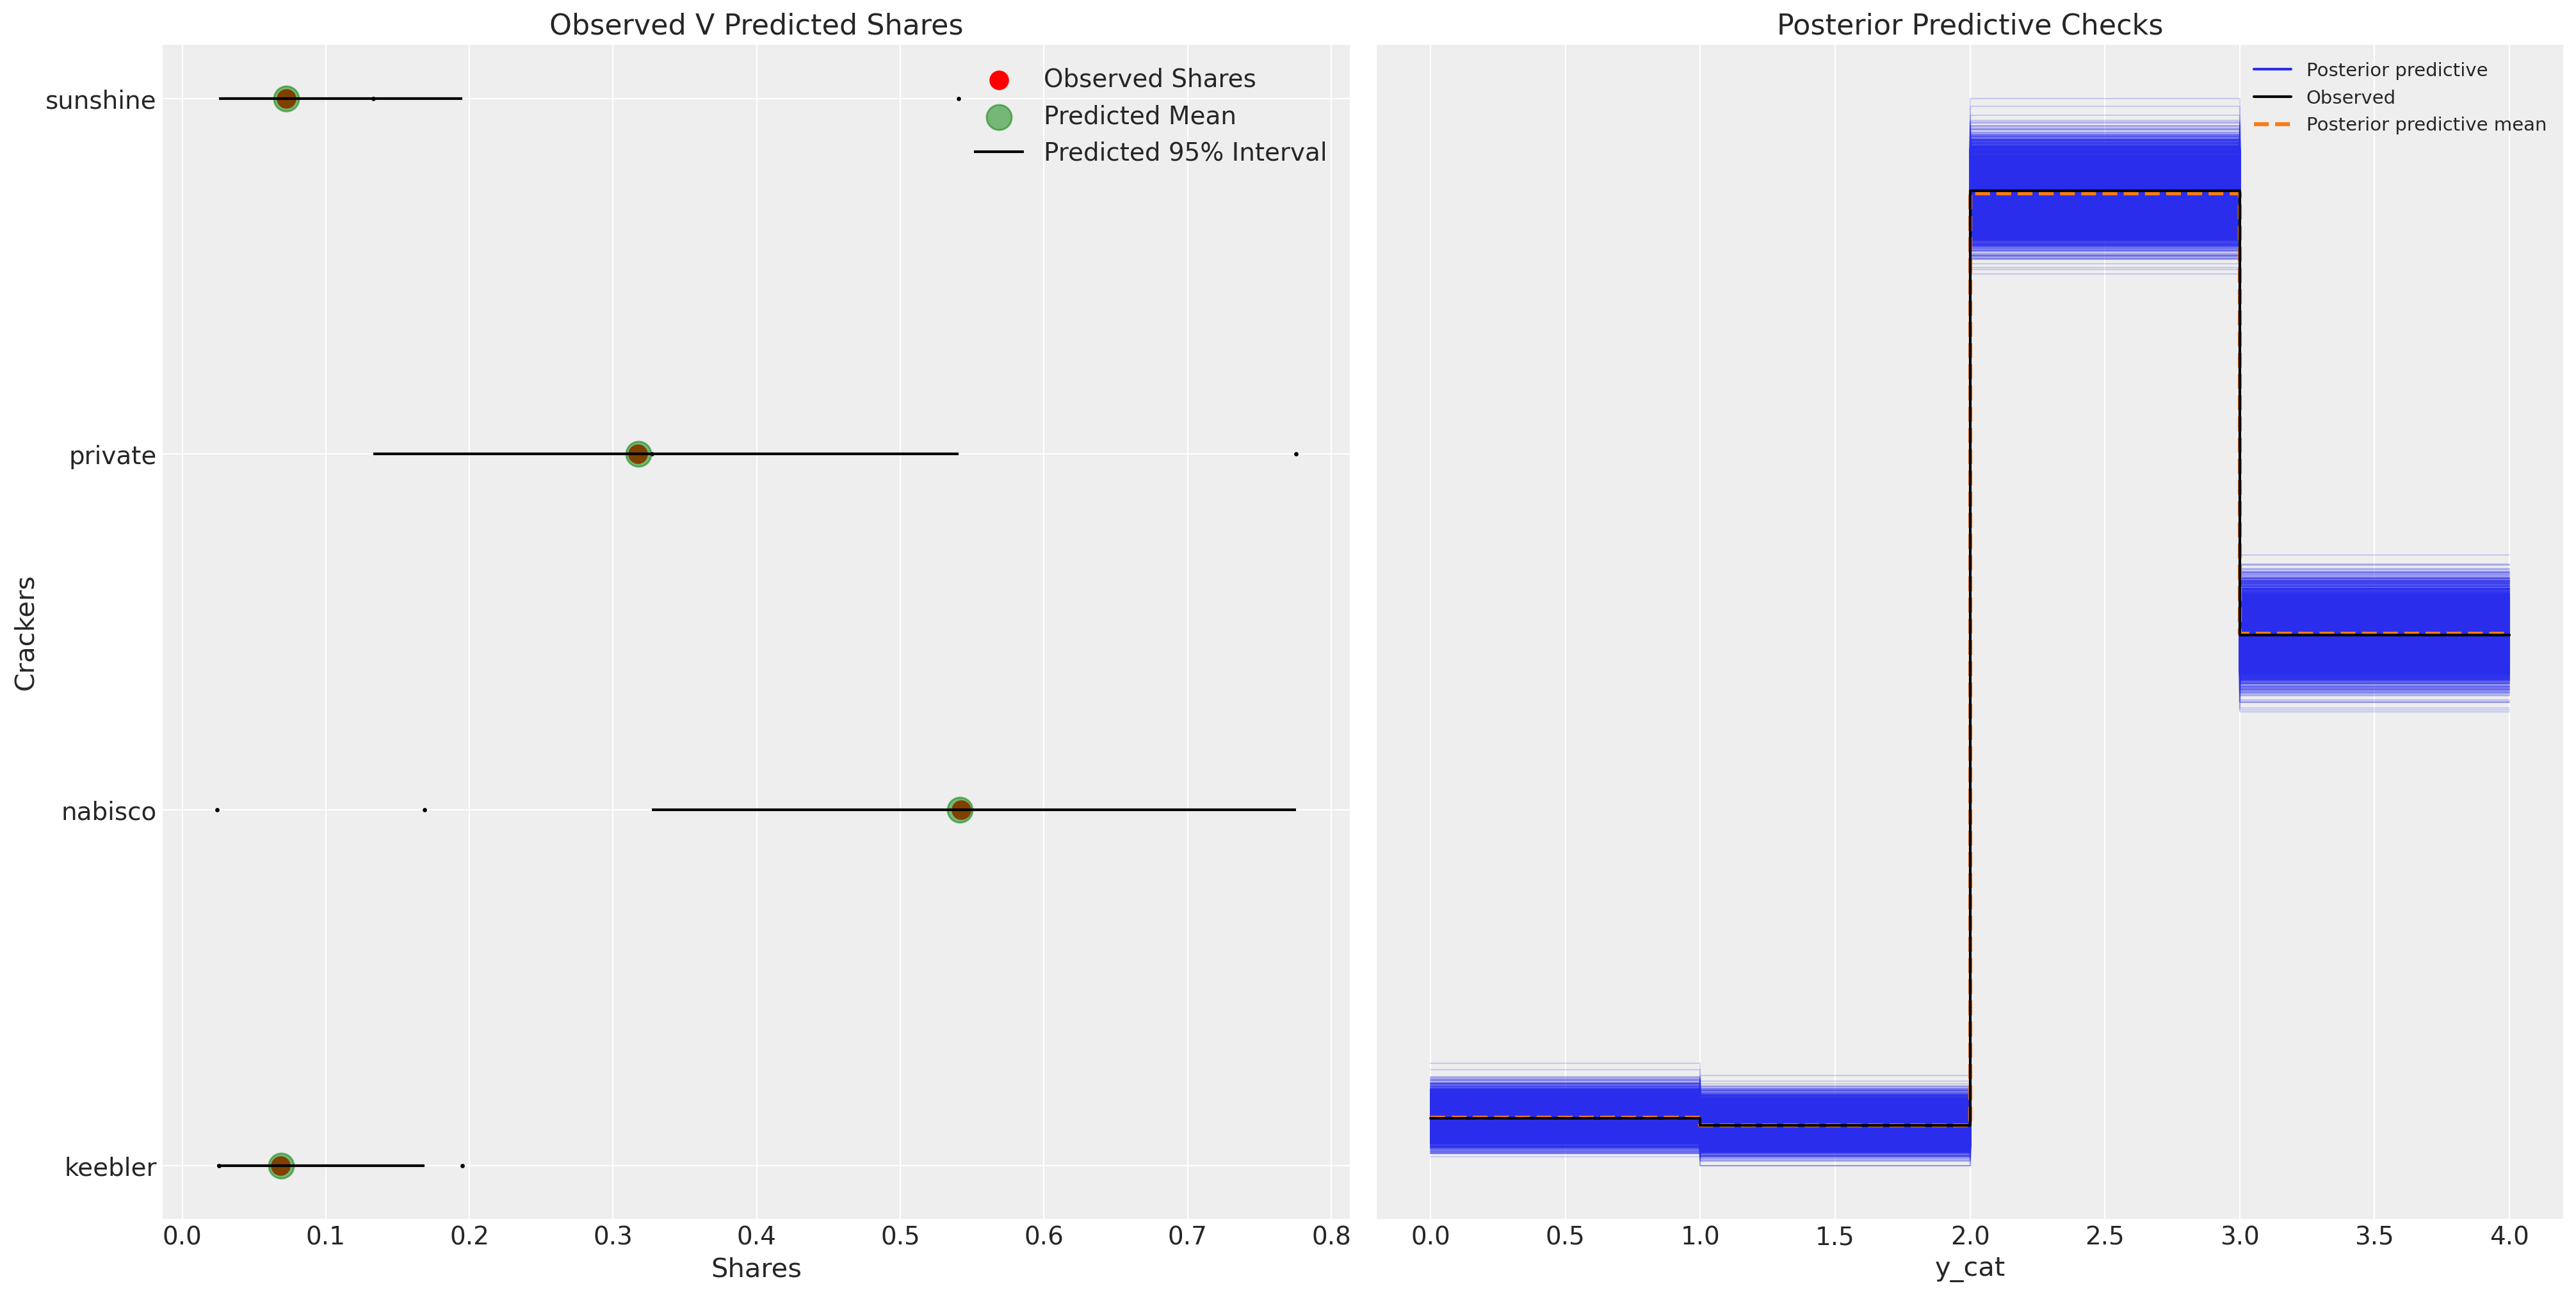

In [32]:
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
ax = axs[0]
counts = c_df.groupby("choice")["choiceId"].count()
labels = c_df.groupby("choice")["choiceId"].count().index
predicted_shares = idata_m4["posterior"]["p"].mean(dim=["chain", "draw", "obs"])
ci_lb = idata_m4["posterior"]["p"].quantile(0.025, dim=["chain", "draw", "obs"])
ci_ub = idata_m4["posterior"]["p"].quantile(0.975, dim=["chain", "draw", "obs"])
ax.scatter(ci_lb, labels, color="k", s=2)
ax.scatter(ci_ub, labels, color="k", s=2)
ax.scatter(
    counts / counts.sum(),
    labels,
    label="Observed Shares",
    color="red",
    s=100,
)
ax.scatter(
    predicted_shares,
    predicted_shares["alts_probs"].values,
    label="Predicted Mean",
    color="green",
    s=200,
    alpha=0.5,
)
ax.hlines(
    predicted_shares["alts_probs"].values,
    ci_lb,
    ci_ub,
    label="Predicted 95% Interval",
    color="black",
)
ax.legend()
ax.set_title("Observed V Predicted Shares")
az.plot_ppc(idata_m4, ax=axs[1])
axs[1].set_title("Posterior Predictive Checks")
ax.set_xlabel("Shares")
ax.set_ylabel("Crackers");

We can now also recover the differences among individuals estimated by the model for particular cracker choices. More precisely we'll plot how the individual specific contribution to the intercept drives preferences among the cracker choices. 

In [33]:
idata_m4

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

In [34]:
beta_individual = idata_m4["posterior"]["beta_individual"]
predicted = beta_individual.mean(("chain", "draw"))
predicted = predicted.sortby(predicted.sel(alts_intercepts="nabisco"))
ci_lb = beta_individual.quantile(0.025, ("chain", "draw")).sortby(
    predicted.sel(alts_intercepts="nabisco")
)
ci_ub = beta_individual.quantile(0.975, ("chain", "draw")).sortby(
    predicted.sel(alts_intercepts="nabisco")
)

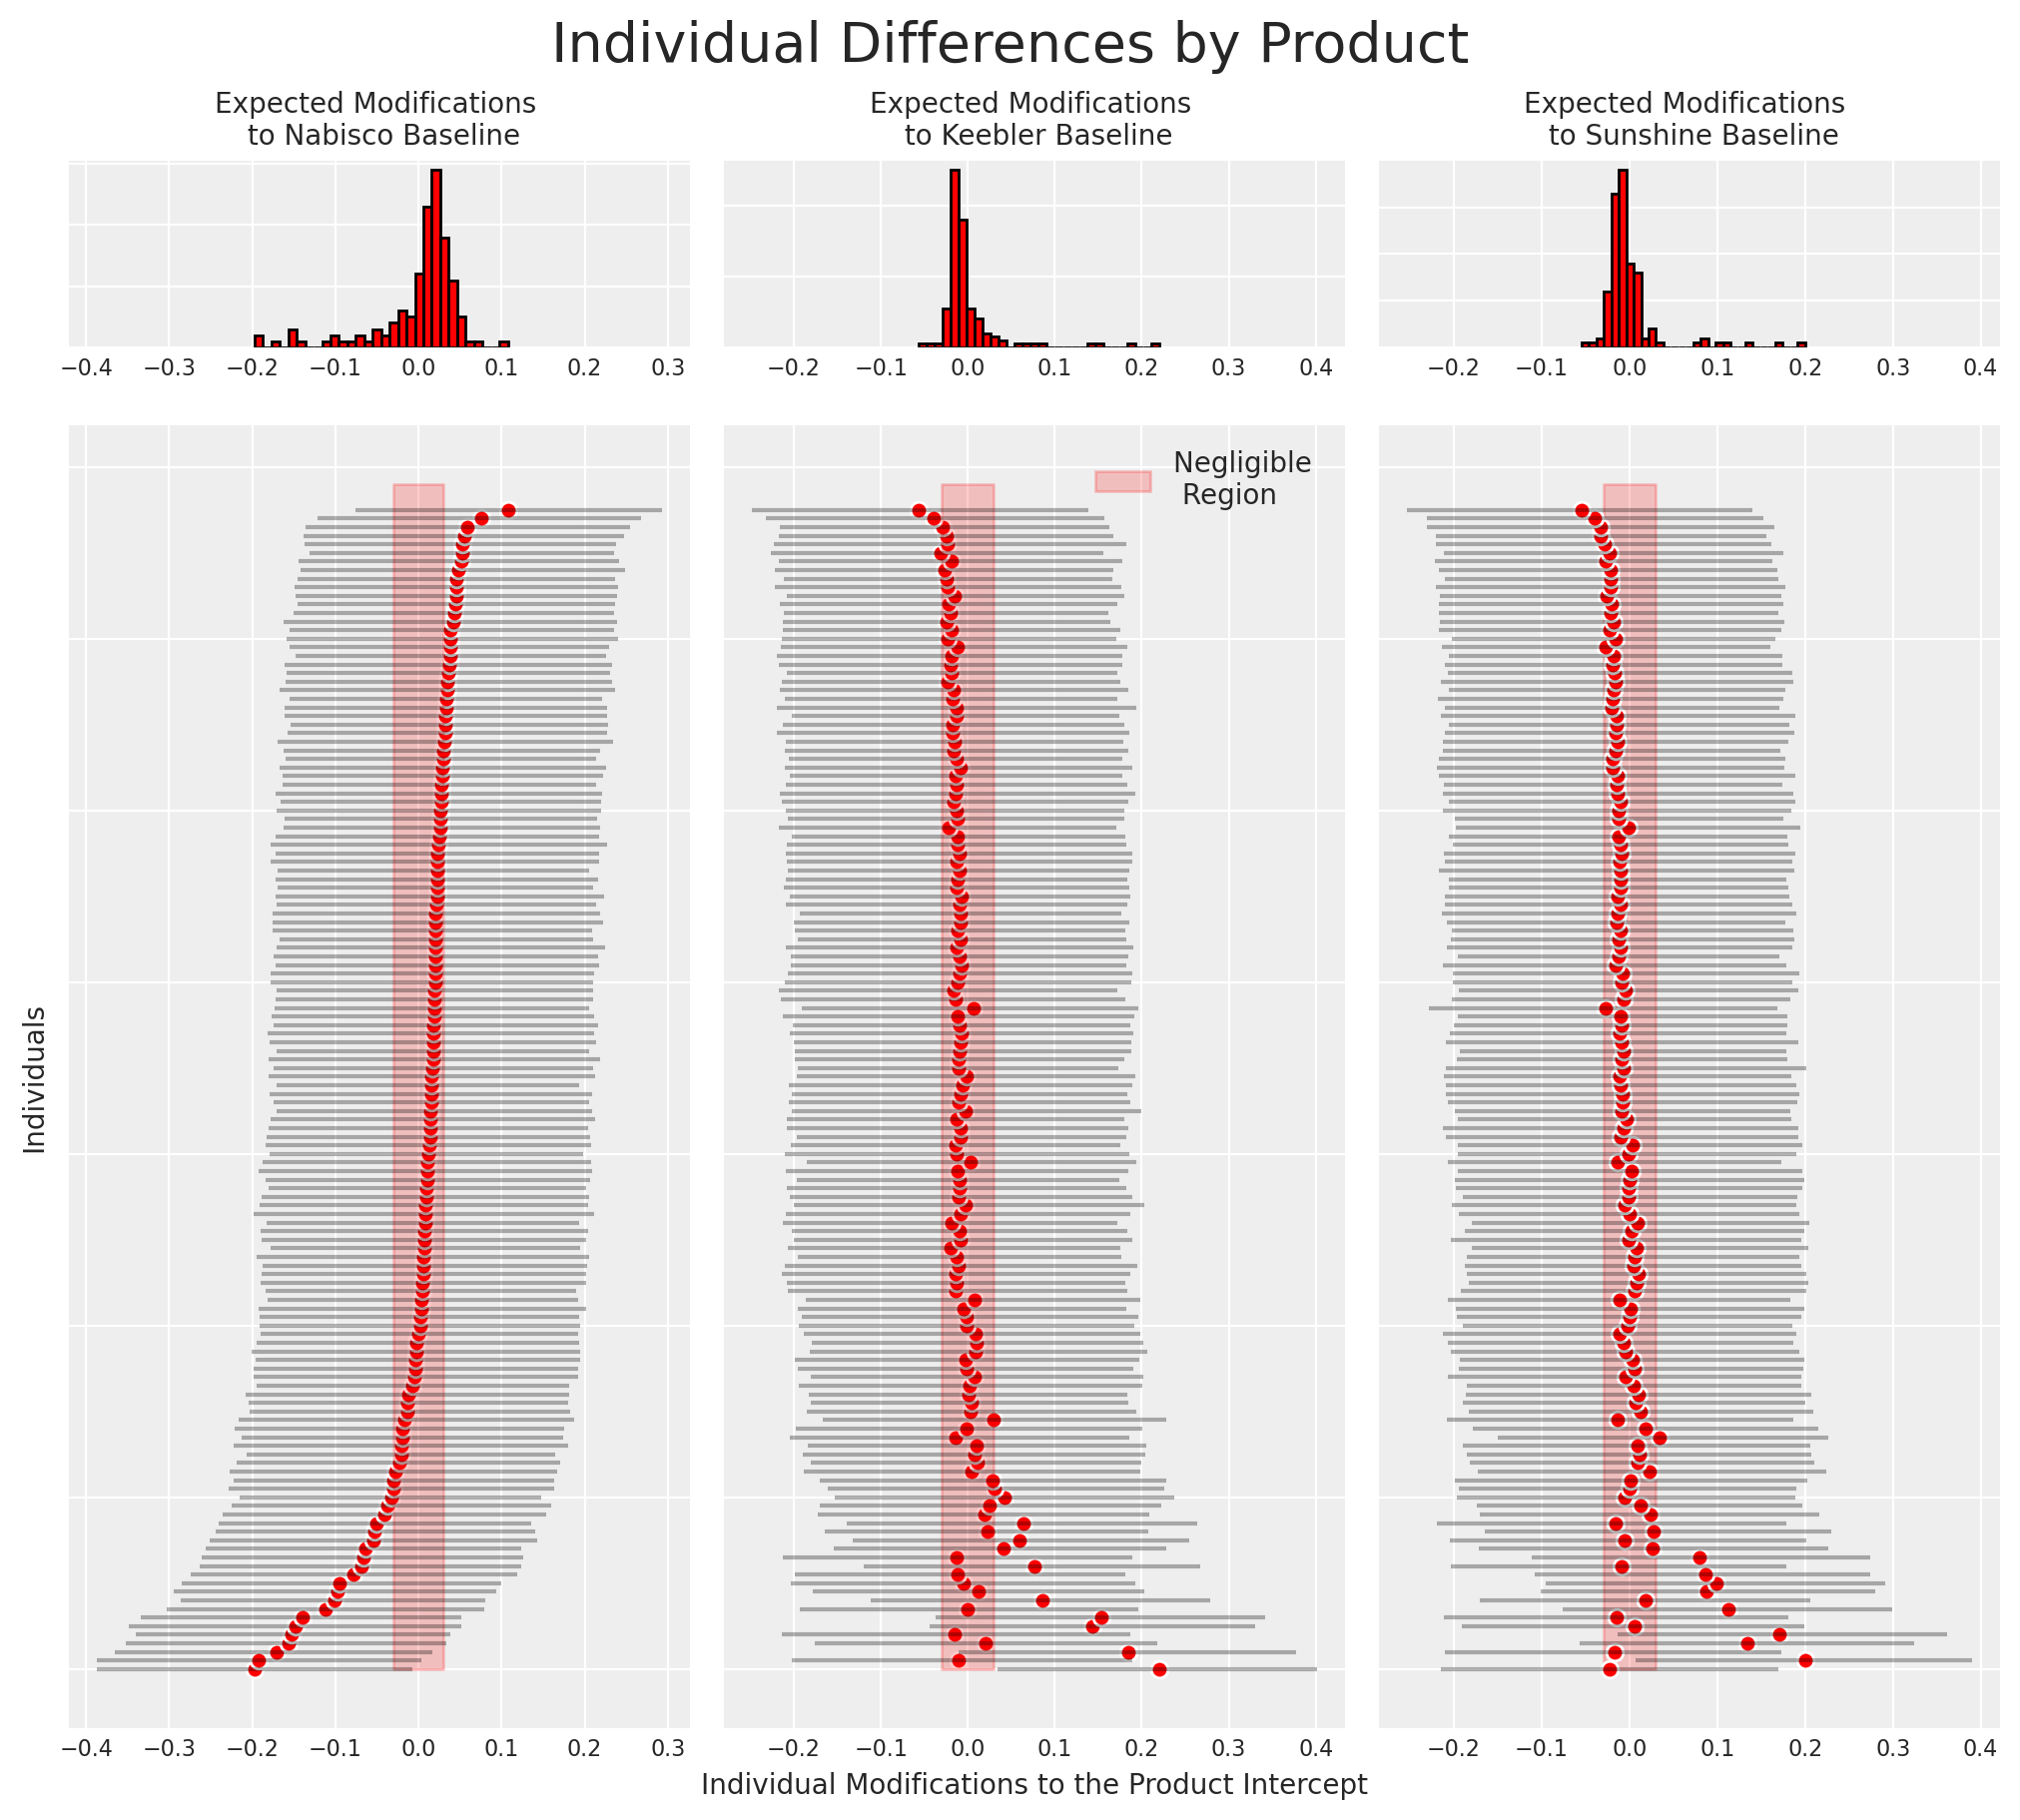

In [35]:
fig = plt.figure(figsize=(10, 9))
gs = fig.add_gridspec(
    2,
    3,
    width_ratios=(4, 4, 4),
    height_ratios=(1, 7),
    left=0.1,
    right=0.9,
    bottom=0.1,
    top=0.9,
    wspace=0.05,
    hspace=0.05,
)
# Create the Axes.
ax = fig.add_subplot(gs[1, 0])
ax.set_yticklabels([])
ax_histx = fig.add_subplot(gs[0, 0], sharex=ax)
ax_histx.set_title("Expected Modifications \n to Nabisco Baseline", fontsize=10)
ax_histx.hist(predicted.sel(alts_intercepts="nabisco"), bins=30, ec="black", color="red")
ax_histx.set_yticklabels([])
ax_histx.tick_params(labelsize=8)
ax.set_ylabel("Individuals", fontsize=10)
ax.tick_params(labelsize=8)
ax.hlines(
    range(len(predicted)),
    ci_lb.sel(alts_intercepts="nabisco"),
    ci_ub.sel(alts_intercepts="nabisco"),
    color="black",
    alpha=0.3,
)
ax.scatter(predicted.sel(alts_intercepts="nabisco"), range(len(predicted)), color="red", ec="white")
ax.fill_betweenx(range(139), -0.03, 0.03, alpha=0.2, color="red")

ax1 = fig.add_subplot(gs[1, 1])
ax1.set_yticklabels([])
ax_histx = fig.add_subplot(gs[0, 1], sharex=ax1)
ax_histx.set_title("Expected Modifications \n to Keebler Baseline", fontsize=10)
ax_histx.set_yticklabels([])
ax_histx.tick_params(labelsize=8)
ax_histx.hist(predicted.sel(alts_intercepts="keebler"), bins=30, ec="black", color="red")
ax1.hlines(
    range(len(predicted)),
    ci_lb.sel(alts_intercepts="keebler"),
    ci_ub.sel(alts_intercepts="keebler"),
    color="black",
    alpha=0.3,
)
ax1.scatter(
    predicted.sel(alts_intercepts="keebler"), range(len(predicted)), color="red", ec="white"
)
ax1.set_xlabel("Individual Modifications to the Product Intercept", fontsize=10)
ax1.fill_betweenx(range(139), -0.03, 0.03, alpha=0.2, color="red", label="Negligible \n Region")
ax1.tick_params(labelsize=8)
ax1.legend(fontsize=10)

ax2 = fig.add_subplot(gs[1, 2])
ax2.set_yticklabels([])
ax_histx = fig.add_subplot(gs[0, 2], sharex=ax2)
ax_histx.set_title("Expected Modifications \n to Sunshine Baseline", fontsize=10)
ax_histx.set_yticklabels([])
ax_histx.hist(predicted.sel(alts_intercepts="sunshine"), bins=30, ec="black", color="red")
ax2.hlines(
    range(len(predicted)),
    ci_lb.sel(alts_intercepts="sunshine"),
    ci_ub.sel(alts_intercepts="sunshine"),
    color="black",
    alpha=0.3,
)
ax2.fill_betweenx(range(139), -0.03, 0.03, alpha=0.2, color="red")
ax2.scatter(
    predicted.sel(alts_intercepts="sunshine"), range(len(predicted)), color="red", ec="white"
)
ax2.tick_params(labelsize=8)
ax_histx.tick_params(labelsize=8)
plt.suptitle("Individual Differences by Product", fontsize=20);

This type of plot is often useful for identifying loyal customers. Similarly it can be used to identify cohorts of customers that ought to be better incentivised if we hope them to switch to our product.

## Conclusion

We can see here the flexibility and richly parameterised possibilities for modelling individual choice of discrete options. These techniques are useful in a wide variety of domains from microeconomics, to marketing and product development. The notions of utility, probability and their interaction lie at the heart of [Savage's Representation theorem](https://plato.stanford.edu/entries/decision-theory/) and justification(s) for Bayesian approaches to statistical inference. So discrete modelling is a natural fit for the Bayesian, but Bayesian statistics is also a natural fit for discrete choice modelling. The traditional estimation techniques are often brittle and very dependent on starting values of the MLE process. The Bayesian setting trades this brittleness for a framework which allows us to incorporate our beliefs about what drives human utility calculations. We've only scratched the surface in this example notebook, but encourage you to further explore the technique. 



## Authors
- Authored by [Nathaniel Forde](https://nathanielf.github.io/) in June 2023 

## References
:::{bibliography}
:filter: docname in docnames
:::

## Watermark

In [36]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor

Last updated: Sat Mar 22 2025

Python implementation: CPython
Python version       : 3.9.16
IPython version      : 8.12.0

pytensor: 2.11.1

numpy     : 1.24.4
pytensor  : 2.11.1
pymc      : 5.3.0
matplotlib: 3.8.2
arviz     : 0.17.0
pandas    : 1.5.3

Watermark: 2.3.1



:::{include} ../page_footer.md
:::